# TimesFM 3.0 × CausalImpact — 実務適用前の検証ノートブック

**目的：** TimesFM 3.0で**介入がなかった場合の結果 Y(0)** を予測し、
CausalImpactのように因果効果の推定に使う際、事前に何を確認すべきかを見ていきます。

中心となる計算はシンプルです。

$$
\hat{\tau}_t = Y_t^{obs} - \hat{Y}_t(0)
$$

このノートブックでは、共通の検証、モデルを使う実益、効果の計算例を分けて扱います。

### Part A — CausalImpactに機械学習を使う際に共通して必要な検証

この部分はTimesFM-3だけの話ではありません。
LightGBM、ニューラルネットワーク、ほかの時系列モデルを反実仮想の予測器に使う場合にも、ほぼそのまま必要になります。

```text
因果仮定と評価ルールを固定
        ↓
過去の複数時点で予測を検証
        ↓
時間プラセボ検証（A/A）
        ↓
既知の効果を注入
        ↓
最後の未使用区間で最終A/A
```

### Part B — その中でも、なぜTimesFM-3なのか？

共通の検証結果とその限界を踏まえながら、
TimesFM-3がCausalImpact型の問題に向いている点を個別に確認します。

```text
zero-shot
+ 対照時系列の過去・予測区間の値を活用
+ 長い予測区間を一度に生成
+ p10〜p90の予測分布
```

### Part C — 設定を固定してから実際の効果を推定

最後に、検証の過程で決めたルールをそのまま使って実際の効果を計算します。

> ここでいうA/Aは、無作為に分けた2群を比較するA/A実験ではなく、  
> **実際には介入がなかった過去に仮の介入時点を置く、時間プラセボ検証（in-time placebo）** を指します。

**使い方：** 上から順番に実行し、各節のパターン別の解釈ガイドに沿って結果を読んでください。ガイドは特定の実行結果を前提とせず、自動的な合格判定も行いません。修正前の実行出力は削除しています。


## 実行環境

推奨：**Colab T4 GPU以上**

TimesFM 3.0の事前学習済み重みには `TimesFM Non-Commercial License v1.0` が適用されます。
業務やサービスに適用する前に、ライセンスを確認してください。


In [1]:
!pip install -q "timesfm[torch]==3.0.0" matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 2.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from timesfm3 import TimesFM3Forecaster

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### Hugging Faceのモデルへのアクセス

`google/timesfm-3.0-pytorch` の利用条件への同意が必要な場合：

1. Hugging Faceのモデルページで利用条件に同意する
2. Colabのシークレットに `HF_TOKEN` を保存する
3. 以下のセルを実行する


In [3]:
try:
    from google.colab import userdata
    from huggingface_hub import login

    hf_token = userdata.get("HF_TOKEN")
    login(token=hf_token, add_to_git_credential=False)
    print("Logged in with HF_TOKEN")
except Exception:
    print(
        "HF login skipped. If download returns 401/403, "
        "accept the model terms and set a Colab Secret named HF_TOKEN."
    )

HF login skipped. If download returns 401/403, accept the model terms and set a Colab Secret named HF_TOKEN.


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch",
    device=DEVICE,
    per_core_batch_size=8,
)

QUANTILES = np.asarray(forecaster.config.quantiles, dtype=float)

print("device:", forecaster.device)
print("max context:", forecaster.global_context)
print("quantiles:", QUANTILES)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.32GB            

model.safetensors: downloading bytes:           |  0.00B            

device: cuda
max context: 15360
quantiles: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


# Part A — 効果を推定する前に何を確認する？

介入がなかった場合の結果を予測した値を、このノートブックでは**反実仮想予測**と呼びます。
観測値からこの予測値を引くと、効果の推定値になります。ただし、予測が外れると、その差も効果のように見えてしまいます。

そこで、次の3点を順に確認します。

- 効果がなかった過去でも、効果があるように見えてしまわないか？
- 知りたい大きさの効果を加えたとき、その効果を検出し、大きさも近く推定できるか？
- 最後に別途残しておいた区間でも、同様の結果が得られるか？

**誤差の数字だけで、大きい・小さいを判断するのは難しいものです。**
まず、1時点の誤差なのか、期間全体を合計した誤差なのかを確認し、普段の結果の水準や知りたい効果の大きさと比べてみます。


# 1. CausalImpactに適した合成データ

CausalImpact/BSTSでよく扱う構造を、理解しやすい形に単純化しました。

$$
\mu_t = \mu_{t-1} + \eta_t
$$

$$
Y_t(0)
=
\mu_t
+
\beta_1 X_{1,t}
+
\beta_2 X_{2,t}
+
\epsilon_t
$$

- μₜ：ゆっくり変化する基礎水準（local level）
- X₁、X₂：介入の影響を受けない対照時系列
- εₜ：観測ノイズ

つまり、**基礎水準 + 季節性を持つ対照時系列 + ノイズ**という構造です。

同じデータ生成過程（DGP）から、効果について2つのケースを作ります。

- **効果なし：** τₜ = 0
- **効果あり：** 介入後にY(0)の10%分だけ上昇

> CausalImpactの原論文のシミュレーションをそのまま再現したものではなく、
> BSTSに適した基本構造を単純化した例です。


In [5]:
PRE = 512
H = 64
TOTAL = PRE + H

t = np.arange(TOTAL, dtype=np.float32)

control_1 = (
    10
    + 2.5 * np.sin(2 * np.pi * t / 30)
    + rng.normal(0, 0.35, TOTAL)
).astype(np.float32)

control_2 = (
    8
    + 1.8 * np.sin(2 * np.pi * t / 7 + 0.8)
    + rng.normal(0, 0.30, TOTAL)
).astype(np.float32)

level_noise = rng.normal(0, 0.20, TOTAL).astype(np.float32)
local_level = 100 + np.cumsum(level_noise)

y0 = (
    local_level
    + 1.4 * control_1
    - 0.9 * control_2
    + rng.normal(0, 0.8, TOTAL)
).astype(np.float32)

effect_none = np.zeros(TOTAL, dtype=np.float32)

effect_positive = np.zeros(TOTAL, dtype=np.float32)
effect_positive[PRE:] = 0.10 * y0[PRE:]

y_null = y0 + effect_none
y_treated = y0 + effect_positive

controls = np.vstack([control_1, control_2]).astype(np.float32)

print("Pre-period:", PRE)
print("Post-period:", H)
print("True cumulative effect (null):", effect_none[PRE:].sum())
print("True cumulative effect (positive):", effect_positive[PRE:].sum())

Pre-period: 512
Post-period: 64
True cumulative effect (null): 0.0
True cumulative effect (positive): 634.7528


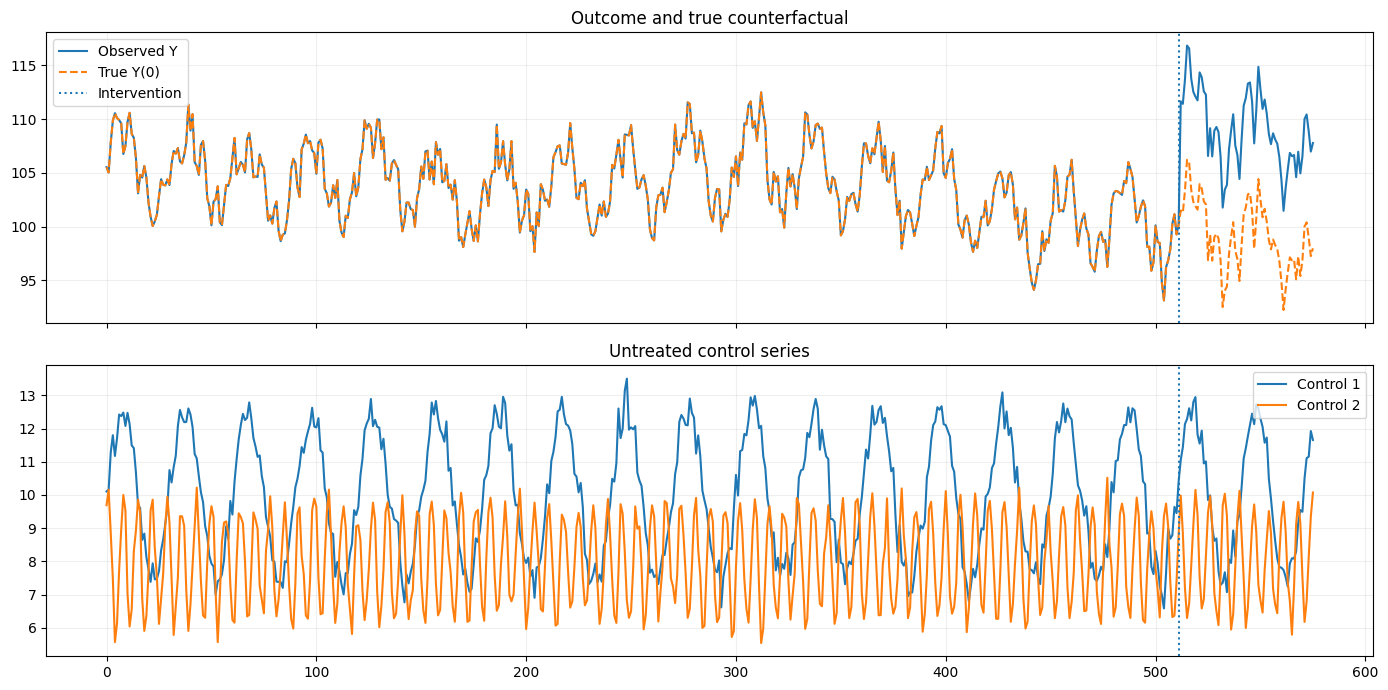

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(t, y_treated, label="Observed Y")
axes[0].plot(t, y0, "--", label="True Y(0)")
axes[0].axvline(PRE - 1, linestyle=":", label="Intervention")
axes[0].set_title("Outcome and true counterfactual")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(t, control_1, label="Control 1")
axes[1].plot(t, control_2, label="Control 2")
axes[1].axvline(PRE - 1, linestyle=":")
axes[1].set_title("Untreated control series")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 2. 分析前にルールと因果仮定を固定する

モデルの性能とは別に、以下の条件が必要です。

### 因果仮定

- 対照時系列は、介入や波及効果の影響を受けていないか？
- 介入がなければ、過去の関係はその後も維持されていたと考えられるか？
- 介入と同時に、ほかの大きな変化が起きていないか？
- 介入前に、すでに反応が始まっていないか？

### 検証ルール

- 実際の効果を64時点にわたって評価するなら、過去の検証も**常に64-step予測**にそろえます。
- 介入後の実際のYを、ラグ、移動平均、モデル更新などに再投入しません。
- 介入の影響を受けない同時点の対照時系列は、事後分析に利用できます。
- 介入前期間の最後の64時点は、モデル選択だけでなく**誤差区間の補正にも使いません。**

つまり、本分析と同じ条件を過去の検証でもそのまま再現します。

この原則はTimesFM-3に限らず、どの機械学習・時系列予測器を使う場合も同じです。


In [7]:
def run_counterfactual(model, y_context, horizon, covariates=None):
    """One-shot H-step forecast. Post-period target Y is never fed back."""
    y_context = np.asarray(y_context, dtype=np.float32)[None, :]

    kwargs = dict(
        context=y_context,
        horizon=horizon,
        return_quantiles=True,
        use_symmetric_averaging=False,
        make_positive=False,
    )

    if covariates is not None:
        kwargs["past_future_covariates"] = np.asarray(
            covariates, dtype=np.float32
        )

    out = model.predict(**kwargs)

    forecast = np.asarray(out.forecast)
    quantiles = np.asarray(out.quantiles)

    if forecast.ndim == 2:
        forecast = forecast[0]
    if quantiles.ndim == 3:
        quantiles = quantiles[0]

    return forecast, quantiles



def empirical_error_band(values, level=0.90):
    """
    Cumulative error distribution -> bias and symmetric error radius.
    Diagnostic only; not a formal conformal guarantee.
    """
    values = np.asarray(values, dtype=float)
    bias = np.median(values)
    radius = np.quantile(np.abs(values - bias), level)
    return bias, radius


def leave_one_out_band(values, i, level=0.90):
    others = np.delete(np.asarray(values, dtype=float), i)
    return empirical_error_band(others, level=level)

# 3. 過去の複数区間でも予測が合うかを確認する

実際の分析で先の64時点を予測するなら、過去の検証でも同じく64時点を予測します。
予測を始める時点を変えて繰り返すと、どの区間では合い、どの区間では外れるのかが分かります。
このように一度に評価する区間を**検証ウィンドウ**と呼びます。

モデルと入力変数の設定は共通です。予測区間の結果変数をモデルに再投入しません。
介入の影響を受けない対照時系列も、本分析と同じ方法で使います。
最後の64時点は、後の最終検証のために残しておきます。

| 確認したいこと | 表・グラフで見るところ |
|---|---|
| 観測値の水準や動きを追えているか？ | ウィンドウごとに観測値と予測値を重ねて見ます。 |
| 1時点あたり、通常どのくらい外れるか？ | 誤差の絶対値を平均したMAEを見ます。 |
| 高め、または低めの予測が続いていないか？ | 符号を残したまま平均した、平均符号付き誤差（ME）を見ます。 |
| 開始時点を変えたり、遠い先を予測したりすると誤差が増えるか？ | ウィンドウ別MAEと、16時点ずつに分けたMAEを比較します。 |

誤差は**観測値−予測値**で計算します。検証ウィンドウkと予測ホライズンhについて：

$$
e_{k,h}=Y_{k,h}-\hat Y_{k,h}(0)
$$

$$
\mathrm{MAE}_k=\frac{1}{H}\sum_{h=1}^{H}|e_{k,h}|,
\qquad
\mathrm{ME}_k=\frac{1}{H}\sum_{h=1}^{H}e_{k,h}
$$

MAEは方向を除いて**どのくらい外れたか**、MEは**どちらに偏ったか**を表します。
MEが正なら実際より低く、負なら実際より高く予測したことになります。

### MAEが2なら、小さな誤差なのか？

理解のため、1日の平均結果が100の例を考えます。この数字は今回の実行結果ではありません。
MAEが2なら、1日あたり平均2だけ外れたという意味で、普段の水準の2%に相当します。
1日の平均結果が10なら、同じMAE 2でも20%です。
そこで以下の表には、**観測平均**と**MAEが観測平均に占める割合**も表示します。

ただし、2%だからといって十分に正確だとは限りません。
知りたい変化が1日あたり+1なのか+10なのかによって、必要な精度が変わるためです。
また、MAEだけで累積効果の誤差を計算することはできません。
毎日+2ずつ同じ方向に外れると、64日間の累積誤差は+128ですが、
+2と−2が交互に現れれば、MAEが同じでも累積誤差は0になり得ます。

**表のMAEの割合は、MAE÷観測平均×100です。時点別の誤差率を平均するMAPEとは異なります。**
このノートブックの正の結果変数で規模を把握するための参考値です。結果が0に近いデータや、正負を行き来するデータには、そのまま適用しません。

現在の設定ではウィンドウが重なります。表や図は観測したウィンドウ間の比較として読み、互いに独立した実験としては数えません。
ここでは予測の形と誤差を確認し、次の節で、その誤差がどのくらいの見かけの累積効果につながるかを見ます。


In [8]:
CONTEXT = 256
DEV_H = H
FINAL_AA_CUT = PRE - H

# Overlapping windows are descriptive diagnostics, not independent trials.
DEV_CUTS = np.arange(
    CONTEXT,
    FINAL_AA_CUT - DEV_H + 1,
    16,
    dtype=int,
)

rows = []
actual_paths = []
forecast_paths = []
placebo_paths = []

for cut in DEV_CUTS:
    start = cut - CONTEXT
    actual = y0[cut:cut + DEV_H]
    forecast, _ = run_counterfactual(
        forecaster,
        y_context=y0[start:cut],
        horizon=DEV_H,
        covariates=controls[:, start:cut + DEV_H],
    )
    error = actual - forecast
    actual_paths.append(actual)
    forecast_paths.append(forecast)
    placebo_paths.append(error)
    rows.append({
        "예측 시작점": cut,
        "MAE": np.mean(np.abs(error)),
        "관측 평균": np.mean(actual),
        "MAE / 관측 평균 (%)": 100 * np.mean(np.abs(error)) / np.mean(actual),
        "평균 부호 오차 (관측−예측)": np.mean(error),
    })

actual_paths = np.asarray(actual_paths)
forecast_paths = np.asarray(forecast_paths)
placebo_paths = np.asarray(placebo_paths)
backtest = pd.DataFrame(rows)

display(backtest)
display(pd.Series({
    "검증 창 수 (서로 겹침)": len(DEV_CUTS),
    "창별 MAE 중앙값": backtest["MAE"].median(),
    "창별 MAE 최댓값": backtest["MAE"].max(),
}))

,예측 시작점,MAE,관측 평균,MAE / 관측 평균 (%),평균 부호 오차 (관측−예측)
0,256,1.305057,105.453987,1.237560,1.143004
1,272,1.066406,105.916595,1.006836,0.637930
2,288,0.994719,105.324829,0.944430,0.594236
3,304,1.250150,105.711487,1.182606,1.149795
4,320,0.843441,104.604752,0.806313,-0.239029
5,336,1.094656,104.523117,1.047286,-0.981061
6,352,1.062027,103.597923,1.025143,-0.602010
7,368,1.802250,103.123962,1.747654,-1.794038
8,384,1.961218,101.798943,1.926560,-1.725563


,0
검증 창 수 (서로 겹침),9.000000
창별 MAE 중앙값,1.094656
창별 MAE 최댓값,1.961218


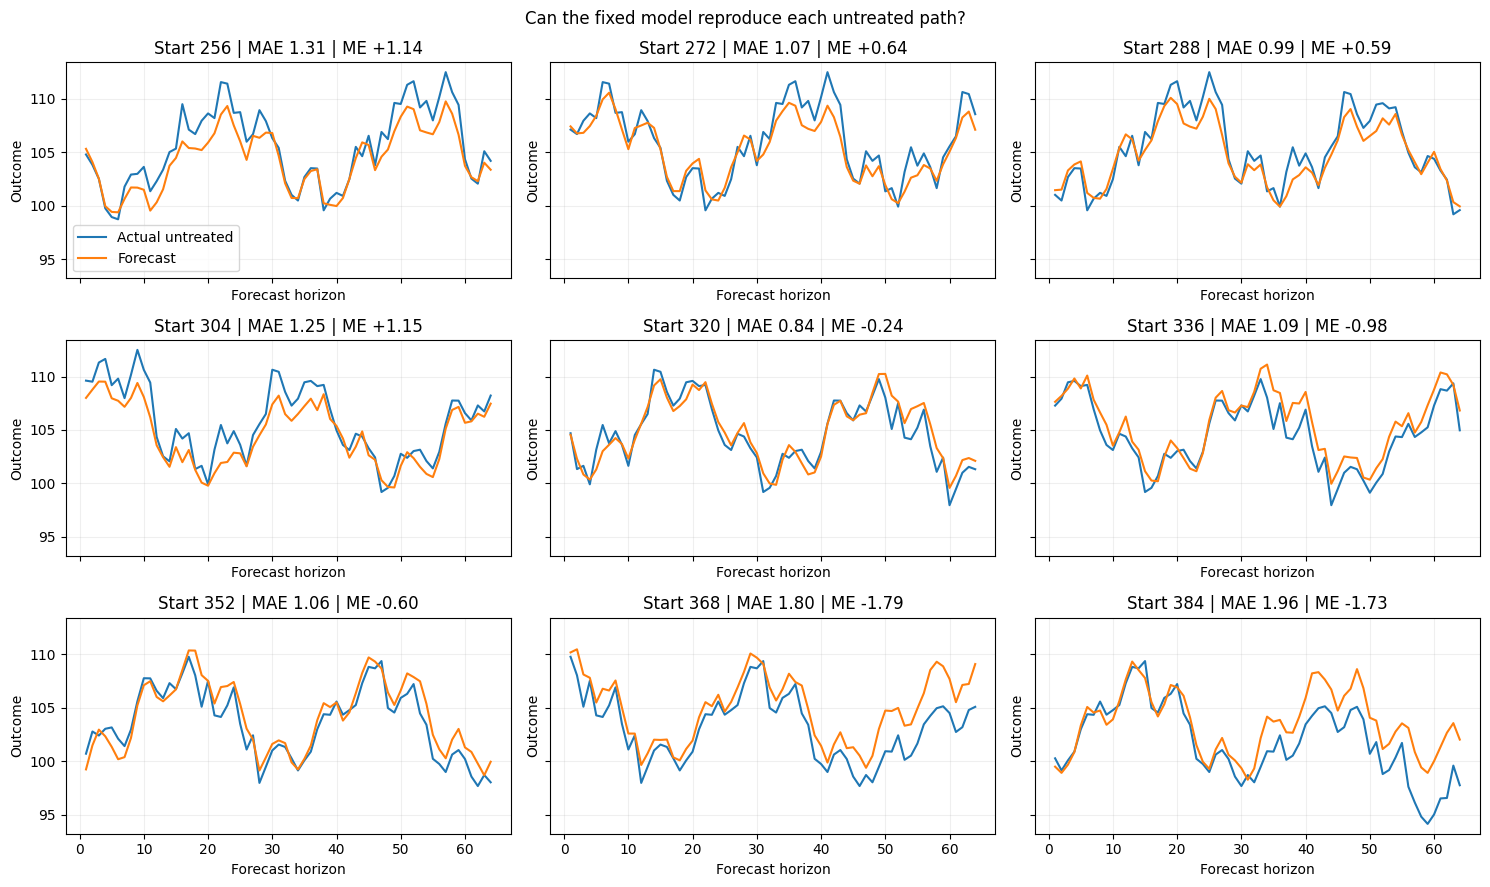

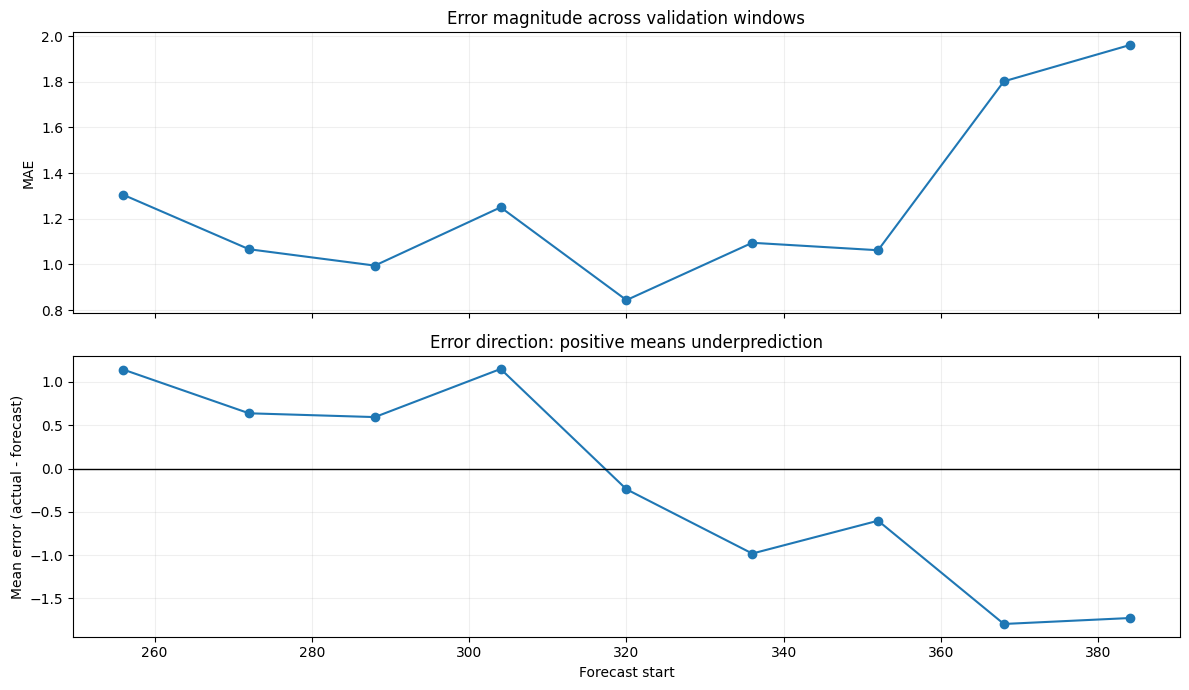

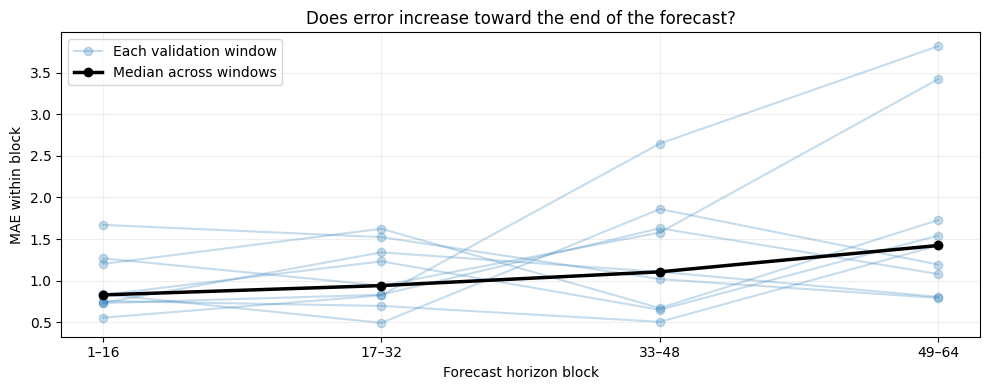

In [9]:
# Show every window; do not select only well-fitting examples.
horizons = np.arange(1, DEV_H + 1)
ncols = 3
nrows = int(np.ceil(len(DEV_CUTS) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(15, 3 * nrows), sharex=True, sharey=True,
    squeeze=False,
)
for i, ax in enumerate(axes.flat):
    if i >= len(DEV_CUTS):
        ax.set_visible(False)
        continue
    ax.plot(horizons, actual_paths[i], label="Actual untreated")
    ax.plot(horizons, forecast_paths[i], label="Forecast")
    ax.set_title(
        f"Start {DEV_CUTS[i]} | MAE {np.abs(placebo_paths[i]).mean():.2f}"
        f" | ME {placebo_paths[i].mean():+.2f}"
    )
    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("Outcome")
    ax.grid(alpha=0.2)
axes[0, 0].legend()
fig.suptitle("Can the fixed model reproduce each untreated path?")
plt.tight_layout()
plt.show()

# Separate error magnitude from error direction across forecast starts.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(DEV_CUTS, backtest["MAE"], marker="o")
axes[0].set_title("Error magnitude across validation windows")
axes[0].set_ylabel("MAE")
axes[1].plot(
    DEV_CUTS, backtest["평균 부호 오차 (관측−예측)"], marker="o",
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Error direction: positive means underprediction")
axes[1].set_ylabel("Mean error (actual - forecast)")
axes[1].set_xlabel("Forecast start")
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Compare early and late forecast errors without hiding window variation.
block_starts = np.arange(0, DEV_H, 16)
block_labels = [f"{s + 1}–{min(s + 16, DEV_H)}" for s in block_starts]
block_mae = np.column_stack([
    np.abs(placebo_paths[:, s:s + 16]).mean(axis=1)
    for s in block_starts
])
fig, ax = plt.subplots(figsize=(10, 4))
for i, values in enumerate(block_mae):
    ax.plot(
        np.arange(len(block_starts)), values, "o-", alpha=0.25,
        color="tab:blue", label="Each validation window" if i == 0 else None,
    )
ax.plot(
    np.arange(len(block_starts)), np.median(block_mae, axis=0),
    "o-", color="black", linewidth=2.5, label="Median across windows",
)
ax.set_xticks(np.arange(len(block_starts)), block_labels)
ax.set_xlabel("Forecast horizon block")
ax.set_ylabel("MAE within block")
ax.set_title("Does error increase toward the end of the forecast?")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### グラフがこのように見えたら、どう読む？

| 観察される様子 | 読み方 |
|---|---|
| 上下する形は似ているが、予測線がずっと上か下にある。 | 動きは追えても、水準が合っていません。MEを見て、次の節でこの差がどのくらい累積するかを確認します。 |
| 特定のウィンドウだけMAEが大きい。 | 時期によって予測が難しい可能性があります。その図で、いつから2本の線が離れるかを見てください。 |
| 複数のウィンドウでMEが同じ符号になる。 | 正なら低め、負なら高めの予測が繰り返されています。効果の推定も一方向に偏る可能性があります。 |
| 開始時点によってMEの符号が変わる。 | 全体平均では相殺されることがあります。平均だけで判断せず、各ウィンドウを見てください。 |
| 複数のウィンドウで予測後半のMAEが増える。 | 遠い先ほど予測が難しい可能性があります。効果を評価する期間の最後まで、必要な精度が維持されるかを見てください。 |
| 一部のウィンドウだけ後半のMAEが増える。 | 遠い先を予測したためか、その時期に変化があったためかを併せて見ます。重なるウィンドウが同じ変化を示している可能性もあります。 |
| 2本の線が近く、ウィンドウ別の誤差も似ている。 | 観測した区間では比較的安定しています。次に、誤差の大きさを関心のある効果と比べ、A/Aの結果も確認します。 |

**MEが0に近くても、毎時点の予測が正確とは限りません。** 大きな正負の誤差が相殺されていないか、MAEと予測経路の図を併せて見てください。


# 4. 効果がないのに、効果があるように見えないか？ — 時間A/A

今度は、3節の誤差を64時点分合計します。
介入がなかった区間なので、真の効果は0です。しかし、予測が外れると合計が0にならないことがあります。
この合計を**見かけの累積効果**と呼びます。

$$
E_k=\sum_{h=1}^{H}e_{k,h}=H\times\mathrm{ME}_k
$$

### まず数字の単位を確認する

3節のMEは**1時点あたりの平均差**、この節の累積効果は**期間全体の差**です。
累積差2と、1日あたり平均差2は同じ大きさではありません。
たとえば64日間の累積差が2なら1日平均は約0.03、
累積差が10なら1日平均は約0.16です。
どちらも数字だけで小さいと決めず、以下のように比較対象を定めます。

### 累積誤差300は、どのくらい大きい？

**1日平均100、評価期間64日**という説明用の例を見ます。
介入がない場合の64日間の合計は6,400です。累積誤差300は1日平均で約4.69、期間合計の約4.69%です。

| 知りたい変化 | その変化の64日間の累積量 | 累積誤差300と比べると |
|---|---:|---|
| +2% | 128 | 誤差は関心のある効果の約2.34倍です。知りたい効果より大きな見かけの効果が生じる可能性があります。 |
| +5% | 320 | 誤差は関心のある効果の約94%です。ほぼ同じ大きさなので、区別が難しい可能性があります。 |
| +10% | 640 | 誤差は関心のある効果の約47%です。効果より小さくても、大きさの推定では無視しにくい可能性があります。 |

これらの数字は説明用であり、合格基準ではありません。
誤差が関心のある効果より小さいだけで、検出や正確な推定が保証されるわけでもありません。
次の節で実際に効果を加えて確認するのは、そのためです。

### 点の位置と区間の幅は、異なる情報を表す

たとえば補正後の点が+10、区間が−290〜+310なら、
点は0に近く見えても、**誤差半径は300**、区間全体の幅は600です。
小さな効果を区別できるほど範囲が狭いかも見る必要があります。
逆に、点が+300だからといって、誤差半径も300とは限りません。

このノートブックでは、過去の累積誤差の中央値を共通の偏りとみなし、差し引きます。
その中央値からの距離の90%分位点を**誤差半径**として、補正した点の両側に付けます。
時点別のp10–p90を合計して作る区間ではありません。
この計算によって、実際に90%の被覆率が保証されるわけではありません。

### 表とグラフを読む順番

1. 元の単位の表で、見かけの累積効果と補正後の点・区間を確認します。
2. 規模を比較する表で、**補正後の見かけの効果が1日平均でいくらか**、**そのウィンドウの観測合計の何%か**、**区間の半径は何%か**を確認します。
3. 割合のグラフを見て、関心のある効果が+2%、+5%、+10%の場合と比べます。これらの割合は合格ラインではありません。

たとえば補正後の見かけの効果が−4%なら、効果がないのに、その期間の合計の4%減少のように見えるという意味です。
観測合計に対する半径が3%なら、補正後の点の両側に、それぞれ3%分の範囲が付くという意味です。
この2つは異なる値なので、併せて読んでください。

各ウィンドウの点と区間は、そのウィンドウ以外のウィンドウで補正します。2つのグラフと表は同じ値を使います。
1つを除いても残りのウィンドウと日付が重なるため、0を含まない割合は、独立した実験の偽陽性率ではなく開発用の参考値です。
全開発ウィンドウで計算した共通の補正値は、後の最終検証と効果推定で使えるよう、別の表に表示します。


In [10]:
AA_LEVEL = 0.90
placebo_cumulative = placebo_paths.sum(axis=1)

aa_rows = []
for i, effect_estimate in enumerate(placebo_cumulative):
    bias_i, radius_i = leave_one_out_band(
        placebo_cumulative,
        i,
        level=AA_LEVEL,
    )

    corrected = effect_estimate - bias_i
    lower = corrected - radius_i
    upper = corrected + radius_i

    aa_rows.append({
        "가짜 개입 시점": DEV_CUTS[i],
        "누적 가짜 효과": effect_estimate,
        "편향 보정 효과": corrected,
        "구간 하한": lower,
        "구간 상한": upper,
        "0 포함": lower <= 0 <= upper,
    })

aa_result = pd.DataFrame(aa_rows)

aa_false_positive_rate = 1 - aa_result["0 포함"].mean()
dev_bias, dev_radius = empirical_error_band(
    placebo_cumulative,
    level=AA_LEVEL,
)

print("Number of placebo windows:", len(placebo_cumulative))
print("Median cumulative bias:", dev_bias)
print("Empirical cumulative-error radius:", dev_radius)
print("Development false-positive diagnostic:", aa_false_positive_rate)

display(aa_result)

# A/A has no intervention: the observed total provides a known size reference.
aa_totals = actual_paths.sum(axis=1).astype(float)
aa_radius = (aa_result["구간 상한"] - aa_result["구간 하한"]).to_numpy() / 2
aa_scale = pd.DataFrame({
    "가짜 개입 시점": DEV_CUTS,
    "관측 합계": aa_totals,
    "보정 후 가짜 효과 / 시점": aa_result["편향 보정 효과"].to_numpy() / DEV_H,
    "보정 후 가짜 효과 / 관측 합계 (%)": 100 * aa_result["편향 보정 효과"].to_numpy() / aa_totals,
    "오차 반경 / 관측 합계 (%)": 100 * aa_radius / aa_totals,
})
display(aa_scale.round(3))

Number of placebo windows: 9
Median cumulative bias: -15.297843933105469
Empirical cumulative-error radius: 96.0146713256836
Development false-positive diagnostic: 0.4444444444444444


,가짜 개입 시점,누적 가짜 효과,편향 보정 효과,구간 하한,구간 상한,0 포함
0,256,73.152275,100.065525,8.381870,191.749181,False
1,272,40.827538,67.740788,-32.455127,167.936702,True
2,288,38.031105,64.944355,-35.251559,165.140269,True
3,304,73.586906,100.500156,8.946890,192.053423,False
4,320,-15.297844,-15.049068,-126.551044,96.452908,True
5,336,-62.787933,-74.154564,-197.271946,48.962818,True
6,352,-38.528656,-49.895287,-173.012669,73.222095,True
7,368,-114.818405,-126.185036,-214.634032,-37.736039,False
8,384,-110.436043,-121.802673,-211.566379,-32.038968,False


,가짜 개입 시점,관측 합계,보정 후 가짜 효과 / 시점,보정 후 가짜 효과 / 관측 합계 (%),오차 반경 / 관측 합계 (%)
0,256,6749.055,1.564,1.483,1.358
1,272,6778.662,1.058,0.999,1.478
2,288,6740.789,1.015,0.963,1.486
3,304,6765.535,1.570,1.485,1.353
4,320,6694.704,-0.235,-0.225,1.666
5,336,6689.479,-1.159,-1.109,1.840
6,352,6630.267,-0.780,-0.753,1.857
7,368,6599.934,-1.972,-1.912,1.340
8,384,6515.132,-1.903,-1.870,1.378


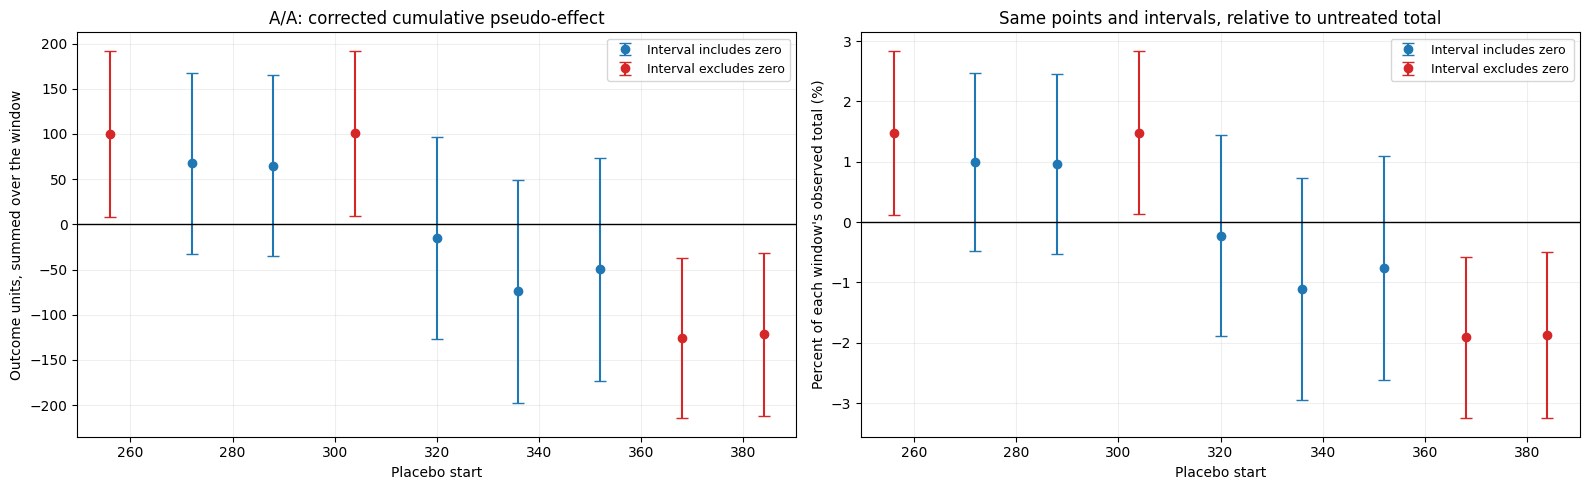

,최종 A/A·효과 추정에 적용할 공통 보정값
개발 창 수 (서로 겹침),9.000000
공통 누적 편향 (전체 개발 창),-15.297844
공통 오차 반경 (전체 개발 창),96.014671
사용한 절대편차 분위수 수준,0.900000


In [11]:
# Left: original units. Right: the same points and intervals divided by each
# untreated window's observed total. Percentages are size references, not p-values.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for includes_zero, color, label in [
    (True, "tab:blue", "Interval includes zero"),
    (False, "tab:red", "Interval excludes zero"),
]:
    mask = (aa_result["0 포함"] == includes_zero).to_numpy()
    group = aa_result.loc[mask]
    if group.empty:
        continue
    center = group["편향 보정 효과"].to_numpy(dtype=float)
    lower = group["구간 하한"].to_numpy(dtype=float)
    upper = group["구간 상한"].to_numpy(dtype=float)
    for ax, multiplier in zip(axes, [np.ones(len(group)), 100 / aa_totals[mask]]):
        ax.errorbar(
            group["가짜 개입 시점"].to_numpy(), center * multiplier,
            yerr=np.vstack([center - lower, upper - center]) * multiplier,
            fmt="o", capsize=4, color=color, label=label,
        )
for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("Placebo start")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
axes[0].set_title("A/A: corrected cumulative pseudo-effect")
axes[0].set_ylabel("Outcome units, summed over the window")
axes[1].set_title("Same points and intervals, relative to untreated total")
axes[1].set_ylabel("Percent of each window's observed total (%)")
plt.tight_layout()
plt.show()

display(pd.Series({
    "개발 창 수 (서로 겹침)": len(placebo_cumulative),
    "공통 누적 편향 (전체 개발 창)": dev_bias,
    "공통 오차 반경 (전체 개발 창)": dev_radius,
    "사용한 절대편차 분위수 수준": AA_LEVEL,
}).rename("최종 A/A·효과 추정에 적용할 공통 보정값"))

### A/Aの結果の読み方

| 観察される様子 | 読み方 |
|---|---|
| 区間が0を含まないウィンドウが繰り返し現れる。 | 効果がないのに、あると判断してしまう兆候です。予測の偏りと区間の作り方を併せて点検してください。 |
| 点と区間が一方向に偏っている。 | 補正後も、高い側または低い側に誤差が残っている可能性があります。3節のMEと関連づけて見てください。 |
| 開始時点によって正負の方向が変わる。 | 過去から求めた1つの共通補正値では、すべての時期の誤差に対応しにくい可能性があります。 |
| 点は0付近にあるが、区間が広い。 | 点だけを見るとよくても、小さな効果を区別しにくい可能性があります。割合の表で半径を読み、関心のある効果と比較してください。 |
| 大半が0を含み、点の誤差と半径も関心のある効果より小さい。 | 観測したウィンドウではよい兆候です。次の節で関心のある効果を直接加え、最後の未使用区間も確認します。 |

**「0を含むか」と「実務で許容できる大きさか」は別の問いです。**
たとえば関心のある効果が+2%なのに区間の半径が5%なら、0を含んでいても小さな効果の検出には広すぎる可能性があります。
半径が小さくても、点が常に一方向に偏るなら、その問題も確認が必要です。


# 5. 既知の仮想効果を加えて検出力を確認する

A/Aだけでよい結果が得られても、十分ではありません。

誤差区間を非常に広くすると見かけの効果は抑えられますが、
本当に知りたい効果もまったく検出できなくなる可能性があります。

そこで、開発区間の実際のYだけに、人為的に次の持続的な効果を加えます。

- +2%
- +5%
- +10%

対照時系列はそのままにして、同じ分析を繰り返します。

確認する点：

- 加えた効果の大きさを、どのくらい正確に復元できるか？
- 累積効果の区間が0を含まず、効果を検出する割合はどのくらいか？

> この検出率も重複する過去のウィンドウを使うため、独立した実験に基づく正式な検出力（power）の推定値ではなく、
> **実務的な感度の点検**として解釈します。


In [12]:
INJECTED_LIFTS = [0.02, 0.05, 0.10]
injection_rows = []

for lift in INJECTED_LIFTS:
    for i in range(len(DEV_CUTS)):
        untreated = actual_paths[i]
        forecast = forecast_paths[i]

        injected = untreated * (1 + lift)
        true_effect_path = injected - untreated
        estimated_effect_path = injected - forecast

        true_cum = true_effect_path.sum()
        estimated_cum = estimated_effect_path.sum()

        # Calibrate only with other A/A windows.
        bias_i, radius_i = leave_one_out_band(
            placebo_cumulative,
            i,
            level=AA_LEVEL,
        )

        corrected = estimated_cum - bias_i
        lower = corrected - radius_i
        upper = corrected + radius_i

        injection_rows.append({
            "주입 효과": f"+{int(lift * 100)}%",
            "가짜 개입 시점": DEV_CUTS[i],
            "실제 누적 효과": true_cum,
            "추정 누적 효과": corrected,
            "상대 오차": (corrected - true_cum) / max(abs(true_cum), 1e-8),
            "효과 검출": not (lower <= 0 <= upper),
        })

injection_result = pd.DataFrame(injection_rows)

injection_summary = (
    injection_result
    .groupby("주입 효과")
    .agg(
        실제_누적효과=("실제 누적 효과", "mean"),
        추정_누적효과=("추정 누적 효과", "mean"),
        평균_절대_상대오차=("상대 오차", lambda x: np.mean(np.abs(x))),
        경험적_검출률=("효과 검출", "mean"),
    )
)

injection_summary

,실제_누적효과,추정_누적효과,평균_절대_상대오차,경험적_검출률
주입 효과,,,,
+10%,668.484131,662.502388,0.119980,1.000000
+2%,133.696671,127.714919,0.599901,0.555556
+5%,334.241669,328.259914,0.239960,1.000000


### パターン別の解釈 — 効果量の復元と感度

| 観察されるパターン | 解釈と次の確認 |
|---|---|
| 大きな効果は検出できるが、小さな効果の検出率は低い。 | この分析で区別できる効果量には限界があるかもしれません。実務で関心のある効果量に該当する行を中心に見てください。 |
| 平均推定効果は真値に近いが、平均絶対相対誤差は大きい。 | ウィンドウごとの過大・過小推定が平均では相殺される可能性があります。各ウィンドウの結果を確認します。 |
| 検出率は高いが、相対誤差も大きい。 | 効果の有無を区別することと、大きさを正確に復元することは異なります。 |
| 検出率が高く、大きさもよく復元できている。 | その効果注入シナリオではよい結果です。ただし、A/Aで見かけの効果が頻発するなら、信頼性の問題は残ります。 |
| A/Aでは大半が0を含むが、注入した効果も検出しにくい。 | 誤差区間が関心のある効果より広い可能性があります。偽陽性の診断と感度を併せて解釈します。 |

現在の検出指標は、方向にかかわらず区間が0を含まないかを数えます。
正の効果を注入しているため、推定の方向も正しいか、個々の推定値と併せて確認します。
この実験は結果変数だけに一定割合の効果を加えるシナリオであり、ほかの効果の形や対照時系列への介入影響の混入までは検証していません。

### ここでの相対誤差は、何と比較している？

4節の割合は、**介入がない場合の期間合計**との比較でした。
ここでの相対誤差は、**加えた効果そのもの**との比較です。
たとえば真の効果が300なのに240と推定したなら、差は−60、絶対相対誤差は20%です。
普段の結果の合計が大きくても、知りたい効果を20%分外したことになります。

逆に、**推定効果が300**というだけで、**誤差が300**とは言えません。
合成データでは真値と比べて誤差を計算できますが、実際の介入では真値が分からないため、A/Aの誤差と経験的区間を参考にします。
上の表の検出率と相対誤差は0〜1の比率です。0.2は20%、1.0は100%と読んでください。


# 6. 最後の未使用区間で最終A/Aを行う

ここでは、開発の過程で**予測検証、A/A区間の補正、仮想効果の注入に一度も使っていない**、
介入前期間の最後の64時点を確認します。

この時点では、次の設定をすでに固定したと仮定します。

- モデル
- 入力変数
- 過去の入力長
- 評価期間
- 累積効果の誤差範囲の算出方法

合格基準は、単に「有意でない」ことではありません。

- 累積誤差は実務上許容できるか？
- 開発区間で決めた累積効果の範囲は0を含むか？
- 区間の幅は関心のある効果に対して広すぎないか？


In [13]:
final_start = FINAL_AA_CUT - CONTEXT
final_cov = controls[:, final_start:PRE]

final_cf, _ = run_counterfactual(
    forecaster,
    y_context=y0[final_start:FINAL_AA_CUT],
    horizon=H,
    covariates=final_cov,
)

final_actual = y0[FINAL_AA_CUT:PRE]
final_aa_effect = final_actual - final_cf
final_cumulative = float(final_aa_effect.sum())

# IMPORTANT: calibration uses development A/A only.
final_corrected = final_cumulative - dev_bias
final_lower = final_corrected - dev_radius
final_upper = final_corrected + dev_radius

display(pd.Series({
    "MAE": np.mean(np.abs(final_actual - final_cf)),
    "평균 부호 오차 (관측−예측)": np.mean(final_actual - final_cf),
    "누적 가짜 효과": final_cumulative,
    "편향 보정 누적 효과": final_corrected,
    "누적효과 구간 하한": final_lower,
    "누적효과 구간 상한": final_upper,
    "0 포함": final_lower <= 0 <= final_upper,
}))

# Use this untreated held-out window's total only as a descriptive size reference.
final_total = float(final_actual.sum())
display(pd.Series({
    "미사용 구간 관측 합계": final_total,
    "보정 후 가짜 효과 / 시점": final_corrected / H,
    "보정 후 가짜 효과 / 관측 합계 (%)": 100 * final_corrected / final_total,
    "공통 오차 반경 / 관측 합계 (%)": 100 * dev_radius / final_total,
}).rename("마지막 A/A: 오차의 크기 읽기"))

,0
MAE,0.929034
평균 부호 오차 (관측−예측),0.50841
누적 가짜 효과,32.538216
편향 보정 누적 효과,47.83606
누적효과 구간 하한,-48.178612
누적효과 구간 상한,143.850731
0 포함,True


,마지막 A/A: 오차의 크기 읽기
미사용 구간 관측 합계,6430.693848
보정 후 가짜 효과 / 시점,0.747438
보정 후 가짜 효과 / 관측 합계 (%),0.743871
공통 오차 반경 / 관측 합계 (%),1.493069


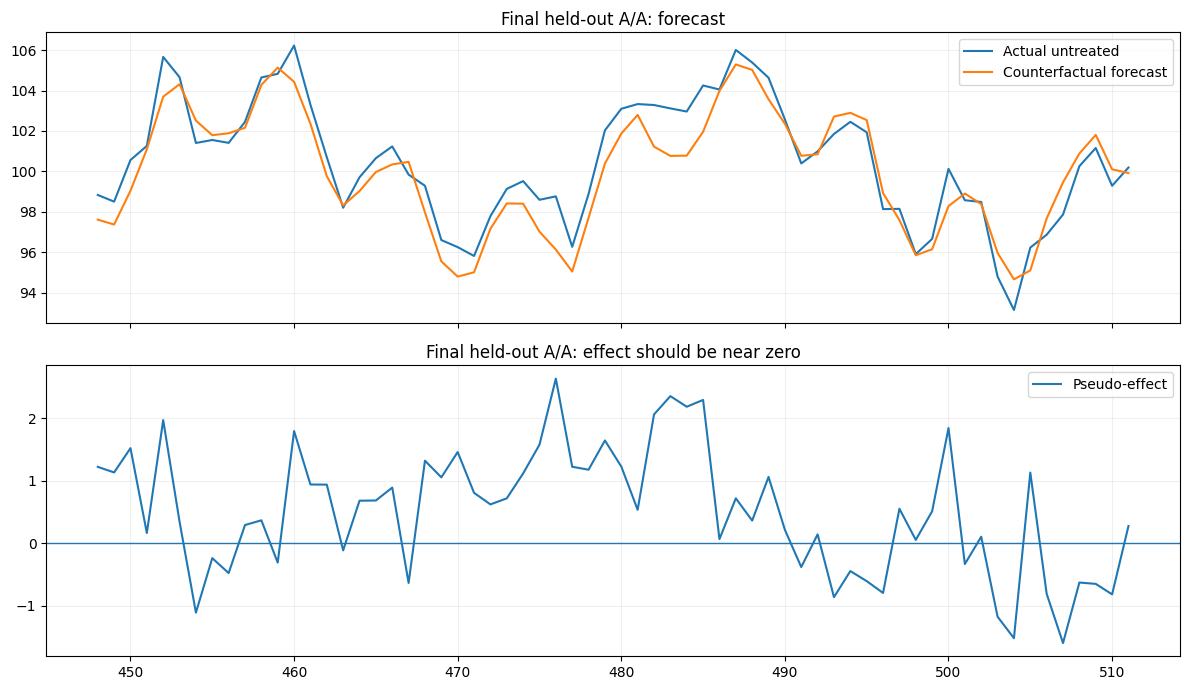

In [14]:
x_final = np.arange(FINAL_AA_CUT, PRE)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(x_final, final_actual, label="Actual untreated")
axes[0].plot(x_final, final_cf, label="Counterfactual forecast")
axes[0].set_title("Final held-out A/A: forecast")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(x_final, final_aa_effect, label="Pseudo-effect")
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Final held-out A/A: effect should be near zero")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### パターン別の解釈 — 最後の未使用区間

| 観察されるパターン | 解釈と次の確認 |
|---|---|
| 0を含み、誤差の大きさも開発区間と似ている。 | この未使用区間では、開発時の診断と整合的な結果です。1区間だけで検証全体に合格したとは判断しません。 |
| 0を含むが、区間が関心のある効果より広い。 | 効果なしと小さな効果を十分に区別できない可能性があります。 |
| 0を含まない、または開発区間より誤差が大きい。 | 開発区間の予測・補正の特性が、その後も維持されているかを再検討してください。 |
| 最後の区間は良好だが、開発A/Aでは問題が繰り返される。 | 最後の1回の結果で、開発区間の偏りや偽陽性の問題を覆い隠さないようにします。 |

この結果を見て設定を変えた場合、この区間は新しい設定に対する未使用の検証区間ではなくなります。

規模の比較表は、この最後の区間自体の観測合計を基準にしています。
関心のある効果がその合計の+2%なら、表の見かけの効果の割合と半径を2%と比べてください。
開発区間よりよく見えても、最後の1区間の結果なので、前に繰り返された問題まで解消したとは考えません。


# Part B — その中でも、なぜTimesFM-3なのか？

Part Aの検証は、ほかの機械学習モデルにも適用できます。

ここでは3節と同じ開発区間で共変量の有無を比較し、予測ホライズン別の安定性の診断も参考にしながら、
**TimesFM-3を反実仮想の予測器に使う利点が、このデータでも現れるか**を確認します。

| TimesFM-3の特徴 | CausalImpact型の問題での意味 | このノートブックでの確認方法 |
|---|---|---|
| **Zero-shot** | 介入や仮の介入時点ごとに、モデルを学習し直す必要がない | 過去のすべてのカットオフで、同じ事前学習済みモデルをそのまま使用 |
| **対照時系列の活用** | Yの過去だけでなく、介入の影響を受けない対照時系列の介入後の値も条件に使える | 単変量予測と `+ controls` を直接比較 |
| **長い区間を一度に予測** | 介入後の実際のYを再入力せずに、反実仮想の経路全体を生成できる | 本分析と同じ64-stepのone-shot予測 |
| **分位点予測** | 時点別の予測自体が不安定な区間を、追加モデルなしで確認できる | p10〜p90を表示し、累積因果効果の区間とは分けて扱う |

TimesFM-3の利点は、**因果仮定を解決してくれること**ではなく、

> **別途の学習や特徴量エンジニアリングなしに、有力な反実仮想予測器を素早く用意できること**

に近いといえます。

この比較は、開発区間での追加診断です。結果を見て入力構成を変更する場合、既存の最終A/Aを新構成の未使用検証とはみなせません。変更後の構成で開発検証と補正をやり直し、別の未使用区間を確保する必要があります。


In [15]:
# Assess the value of controls separately from Part A's fixed-model validation.
univariate_mae = []
for i, cut in enumerate(DEV_CUTS):
    forecast_no_cov, _ = run_counterfactual(
        forecaster,
        y_context=y0[cut - CONTEXT:cut],
        horizon=DEV_H,
        covariates=None,
    )
    univariate_mae.append(np.mean(np.abs(actual_paths[i] - forecast_no_cov)))

control_comparison = pd.DataFrame({
    "예측 시작점": DEV_CUTS,
    "TimesFM+대조 MAE": backtest["MAE"].to_numpy(),
    "TimesFM-단변량 MAE": univariate_mae,
})
mae_with_controls = control_comparison["TimesFM+대조 MAE"].mean()
mae_univariate = control_comparison["TimesFM-단변량 MAE"].mean()
control_gain = (
    1 - mae_with_controls / mae_univariate if mae_univariate > 0 else np.nan
)
timesfm3_summary = pd.Series({
    "대조 시계열 사용 MAE": mae_with_controls,
    "단변량 MAE": mae_univariate,
    "대조 시계열 사용 시 MAE 개선률": control_gain,
})
display(control_comparison)
display(timesfm3_summary)

,예측 시작점,TimesFM+대조 MAE,TimesFM-단변량 MAE
0,256,1.305057,1.753503
1,272,1.066406,1.305800
2,288,0.994719,1.156478
3,304,1.250150,1.738248
4,320,0.843441,1.065987
5,336,1.094656,1.144870
6,352,1.062027,1.152703
7,368,1.802250,1.837837
8,384,1.961218,2.023365


,0
대조 시계열 사용 MAE,1.264436
단변량 MAE,1.464310
대조 시계열 사용 시 MAE 개선률,0.136497


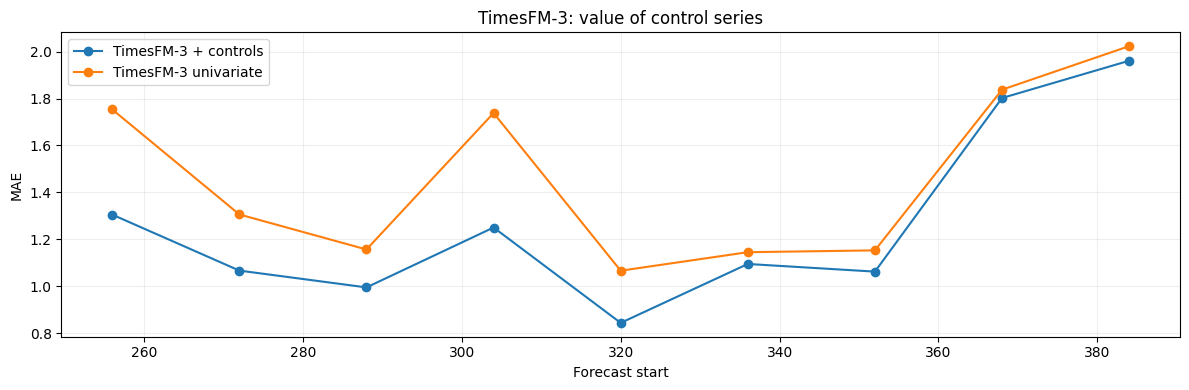

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    DEV_CUTS, control_comparison["TimesFM+대조 MAE"],
    marker="o", label="TimesFM-3 + controls",
)
ax.plot(
    DEV_CUTS, control_comparison["TimesFM-단변량 MAE"],
    marker="o", label="TimesFM-3 univariate",
)
ax.set_title("TimesFM-3: value of control series")
ax.set_xlabel("Forecast start")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### パターン別の解釈 — 対照時系列を使う実益

| 観察されるパターン | 解釈と次の確認 |
|---|---|
| 共変量を加えると、複数のウィンドウで一貫してMAEが小さい。 | そのデータと設定では、対照時系列が予測に寄与する根拠になります。効果推定の信頼性については、Part Aの結果も踏まえて別途判断します。 |
| 改善が小さい、またはウィンドウごとに異なる。 | 対照時系列の追加情報や、モデルがそれを活用する利点が限定的、あるいは時期によって異なる可能性があります。 |
| 共変量を加えると誤差が大きくなる。 | 変数の関連性、時間の対応関係、入力構成を確認してください。この結果だけで原因を特定はしません。 |

3節のホライズン別グラフで後半の誤差が安定していれば、観測した区間では、実際の結果変数を再入力せずに長い経路を予測できる根拠になります。
後半の誤差が増えるなら、長い区間を出力できるという機能と、その区間の精度を区別して見る必要があります。

この比較だけで、TimesFM-3がほかのモデルより優れているとは結論づけません。
後で表示するp10–p90は時点別の予測分位点の範囲です。これを単純に合計して累積因果効果の区間には使いません。


# Part C — 検証結果を踏まえて効果推定の例を確認する

## 8. 固定した分析設定で介入効果を計算する

ここまでの節では、予測精度、見かけの効果、感度、対照時系列を使う実益を確認しました。
コードが最後まで動いたことや、1つのA/A区間が0を含むことは、検証に合格したことを意味しません。

以下は、同じ設定で効果を計算する例です。検証で問題が残っていれば、その限界を踏まえて解釈します。
実務への適用可能性は、関心のある効果量、許容誤差、因果仮定も併せて検討する必要があります。

- TimesFM 3
- 過去の入力長：256
- 対照時系列：`control_1`、`control_2`
- 効果の評価期間：64
- 累積効果の誤差範囲：全開発A/Aの64-step累積誤差で補正

実際の介入後の結果を見て、入力変数や期間を選び直しません。
合成データの真値は、最後の節で計算例の結果を点検するために使います。


In [17]:
real_start = PRE - CONTEXT
real_covariates = controls[:, real_start:PRE + H]

real_cf, real_q = run_counterfactual(
    forecaster,
    y_context=y_treated[real_start:PRE],
    horizon=H,
    covariates=real_covariates,
)

observed_post = y_treated[PRE:]
estimated_effect = observed_post - real_cf
real_cumulative = float(estimated_effect.sum())

real_corrected = real_cumulative - dev_bias
real_lower = real_corrected - dev_radius
real_upper = real_corrected + dev_radius

pd.Series({
    "보정 전 누적 효과": real_cumulative,
    "편향 보정 누적 효과": real_corrected,
    "경험적 구간 하한": real_lower,
    "경험적 구간 상한": real_upper,
    "0 포함": real_lower <= 0 <= real_upper,
    "가짜효과 범위 대비 크기": abs(real_corrected) / max(dev_radius, 1e-8),
})

,0
보정 전 누적 효과,560.765747
편향 보정 누적 효과,576.063591
경험적 구간 하한,480.04892
경험적 구간 상한,672.078262
0 포함,False
가짜효과 범위 대비 크기,5.999745


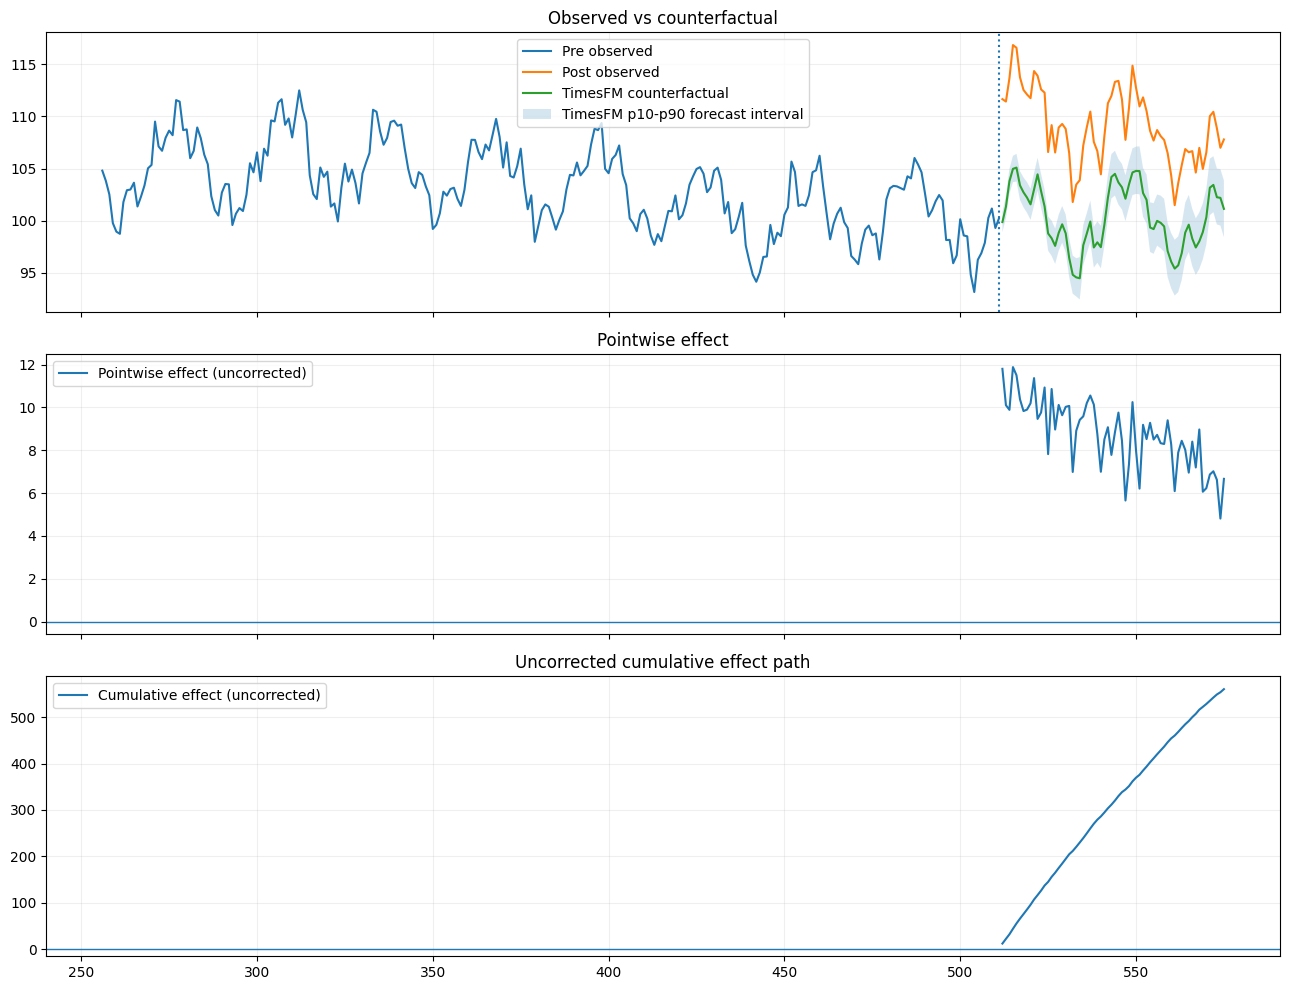

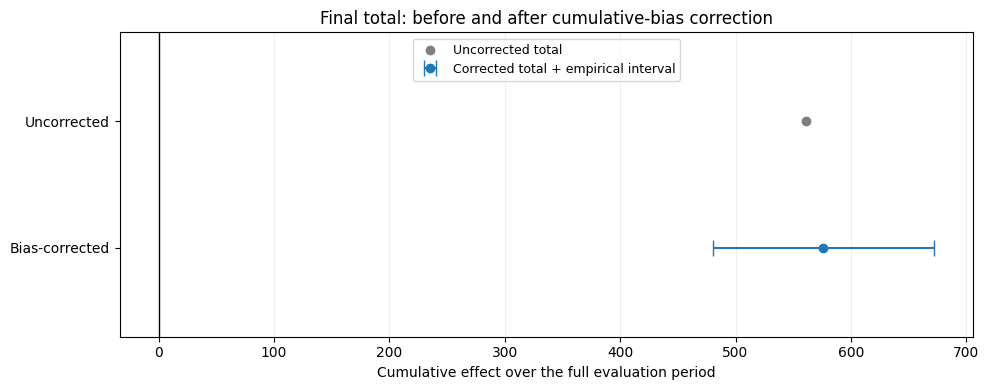

In [18]:
x_post = np.arange(PRE, PRE + H)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(
    np.arange(PRE - CONTEXT, PRE),
    y_treated[PRE - CONTEXT:PRE],
    label="Pre observed",
)
axes[0].plot(x_post, observed_post, label="Post observed")
axes[0].plot(x_post, real_cf, label="TimesFM counterfactual")
q10 = real_q[:, int(np.argmin(np.abs(QUANTILES - 0.1)))]
q90 = real_q[:, int(np.argmin(np.abs(QUANTILES - 0.9)))]
axes[0].fill_between(
    x_post,
    q10,
    q90,
    alpha=0.18,
    label="TimesFM p10-p90 forecast interval",
)
axes[0].axvline(PRE - 1, linestyle=":")
axes[0].set_title("Observed vs counterfactual")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(x_post, estimated_effect, label="Pointwise effect (uncorrected)")
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Pointwise effect")
axes[1].legend()
axes[1].grid(alpha=0.2)

axes[2].plot(
    x_post,
    np.cumsum(estimated_effect),
    label="Cumulative effect (uncorrected)",
)
axes[2].axhline(0, linewidth=1)
axes[2].set_title("Uncorrected cumulative effect path")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Only the H-step total is calibrated; do not invent a corrected daily path.
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(real_cumulative, 1, color="tab:gray", label="Uncorrected total")
ax.errorbar(
    real_corrected, 0,
    xerr=np.array([[real_corrected - real_lower], [real_upper - real_corrected]]),
    fmt="o", capsize=6, color="tab:blue", label="Corrected total + empirical interval",
)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks([0, 1], ["Bias-corrected", "Uncorrected"])
ax.set_ylim(-0.7, 1.7)
ax.set_xlabel("Cumulative effect over the full evaluation period")
ax.set_title("Final total: before and after cumulative-bias correction")
ax.legend(loc="upper center", fontsize=9)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### パターン別の解釈 — 最終効果と補正前後の結果

上の経路図は、**補正前の時点別・累積効果**です。
別に示す総効果の図には、**補正前の最終値**と**補正後の最終値・経験的区間**を、前の要約表と同じ値で表示します。
現在の補正は、評価期間全体の累積誤差に対してのみ行います。これを各時点に任意に配分したり、途中時点の区間へ拡張したりはしません。

| 観察されるパターン | 解釈と次の確認 |
|---|---|
| 補正前後の最終値の差が大きい。 | 過去の累積バイアスの補正が、結論に大きく影響しています。そのバイアスを本分析の区間にも適用できそうかを検討してください。 |
| 経験的区間が0を含む。 | 現在の誤差範囲では0と区別できません。効果がないことの証明ではありません。 |
| 経験的区間が0を含まない。 | 現在の補正方法では0と区別されます。因果仮定やA/Aの問題が解決したことを意味しません。 |
| p10–p90の範囲が広い。 | モデルが出力した時点別の予測範囲が広いという意味です。実際の被覆率や累積効果の区間の妥当性は別の問題です。 |

この1回の結果だけで、一般的な検出力や区間の信頼性について結論は出しません。

### 実際の分析では、何を基準に大きさを読む？

A/Aでは介入がないため、観測合計を基準にできました。
実際の介入後の観測合計には効果が含まれるので、同じように使うと比較の基準が変わります。
まず知りたい効果を累積単位で決め、最終推定値と区間の半径を、その大きさと比べてください。
効果を%で読むには、介入がなかった場合の合計を予測して基準にする必要があります。その基準自体も推定値であることを忘れないでください。

真値が分からない実際の分析で、誤差半径300は**実際に300だけ外れたという意味ではありません。**
過去のA/Aをもとに、点推定値の両側に付けた経験的な範囲です。
関心のある累積効果が100の場合と1,000の場合とでは、この半径の意味が変わります。


# 9. 合成データの真値による最終確認

実際のデータでは、真のY(0)は分かりません。

一方、合成データでは最後に真値を確認して、次の点を点検できます。

- 反実仮想予測が真のY(0)に近いか
- 加えておいた10%の効果をよく復元できたか
- 効果なしのシナリオでは、0に近い効果を推定するか

この段階は実務での事前検証の代わりではなく、**ノートブック自体の基本的な点検**です。


In [19]:
true_cf = y0[PRE:]
true_effect = effect_positive[PRE:]

positive_summary = {
    "시나리오": "효과 있음",
    "실제 누적 효과": true_effect.sum(),
    "보정 후 누적 효과": real_corrected,
    "반사실 MAE": np.mean(np.abs(true_cf - real_cf)),
    "보정 전 시점별 효과 MAE": np.mean(np.abs(true_effect - estimated_effect)),
    "구간에 참 누적효과 포함":
        real_lower <= true_effect.sum() <= real_upper,
}

null_cf, _ = run_counterfactual(
    forecaster,
    y_context=y_null[real_start:PRE],
    horizon=H,
    covariates=real_covariates,
)

null_effect_hat = y_null[PRE:] - null_cf
null_cumulative = float(null_effect_hat.sum())
null_corrected = null_cumulative - dev_bias
null_lower = null_corrected - dev_radius
null_upper = null_corrected + dev_radius

null_summary = {
    "시나리오": "효과 없음",
    "실제 누적 효과": 0.0,
    "보정 후 누적 효과": null_corrected,
    "반사실 MAE": np.mean(np.abs(true_cf - null_cf)),
    "보정 전 시점별 효과 MAE": np.mean(np.abs(null_effect_hat)),
    "구간에 참 누적효과 포함":
        null_lower <= 0 <= null_upper,
}

pd.DataFrame([positive_summary, null_summary])

,시나리오,실제 누적 효과,보정 후 누적 효과,반사실 MAE,보정 전 시점별 효과 MAE,구간에 참 누적효과 포함
0,효과 있음,634.752808,576.063591,1.420385,1.420384,True
1,효과 없음,0.000000,-58.689217,1.420385,1.420385,True


### パターン別の解釈 — 合成データの真値との照合

| 観察されるパターン | 解釈 |
|---|---|
| 推定した累積効果が真値に近い。 | この合成例では、大きさをよく復元できたという意味です。ほかの区間や効果の形でも維持されるかは別途確認が必要です。 |
| 真の累積効果が区間内にある。 | このケースで真値を含んだという結果です。名目水準の被覆率が保証されるわけではありません。 |
| 効果なしのシナリオの推定値が0から離れる。 | 反実仮想予測の誤差、または補正の誤差が、見かけの効果として残っています。 |

表の累積効果は補正後の値であり、時点別効果のMAEは補正前の経路に基づきます。
2つのシナリオは同じ介入前の結果と対照時系列を使うため、独立した2回の検証としては数えません。


## 実務適用のチェックリスト

### A. CausalImpact + MLに共通する検証

#### 因果仮定と情報の流入

- [ ] 対照時系列は介入・波及効果の影響を受けていないか？
- [ ] 介入がなければ、過去の関係はその後も維持されていたと考えられるか？
- [ ] 介入と同時に、ほかの大きな変化はなかったか？
- [ ] 介入後の実際のYを、ラグ・移動平均・モデル更新に使っていないか？

#### 誤差の大きさの読み方

- [ ] 1時点あたりの誤差と、期間全体の累積誤差を区別したか？
- [ ] 誤差を普段の結果の規模だけでなく、知りたい効果量とも比較したか？
- [ ] 点推定値の位置、誤差半径、区間全体の幅を区別したか？

#### 開発区間

- [ ] 本分析と同じ評価長で、過去の複数時点から予測したか？
- [ ] ウィンドウ別の観測・予測経路、MAE・平均符号付き誤差、ホライズンの区間別MAEを確認したか？
- [ ] 時間プラセボ検証で、見かけの効果が一方向に繰り返されていないか？
- [ ] 累積効果の経験的な誤差範囲が広すぎないか？
- [ ] 関心のある効果（+2%、+5%、+10%など）を加えたとき、大きさを近く推定でき、効果も検出できるか？

#### 最後の未使用区間

- [ ] モデル・変数・入力長・評価期間・区間の算出方法を先に固定したか？
- [ ] 最後の区間をモデル選択や区間の補正に使っていないか？
- [ ] 最終A/Aの累積誤差は許容でき、区間は0を含むか？

### B. TimesFM-3を選ぶ追加の理由はあるか？

- [ ] 別途のfine-tuningなしに、zero-shotでも過去の複数区間で安定しているか？
- [ ] 対照時系列を加えると、単変量のTimesFM-3より実際に改善するか？
- [ ] 64-step全体を一度に予測しても、ホライズンの後半で性能が急落しないか？
- [ ] p10〜p90を、時点別の予測の不確実性の確認に活用できるか？
- [ ] これらの利点がなければ、より単純なモデルを使うほうがよくないか？

### C. 実際の結果の解釈

- [ ] TimesFMの日別p10〜p90を単純に合計し、累積因果効果の区間にしていないか？
- [ ] 実際の効果は、開発A/Aで観測された累積誤差の範囲より十分に大きいか？
- [ ] 実際の結果を見た後で、分析設定を選び直していないか？

> **重要な区別**
>
> - Part A：**TimesFM以外でも必要な検証**
> - Part B：**検証結果と限界を踏まえ、TimesFM-3を使う実益があるかを確認**
>
> TimesFM-3の役割は因果仮定を代替することではなく、  
> **zero-shot + 対照時系列 + 長い区間の予測によって、反実仮想モデルの構築コストを下げること**です。


## 参考資料

- Brodersen et al. (2015), *Inferring causal impact using Bayesian structural time-series models*  
  https://arxiv.org/html/1506.00356v1
- CausalImpact公式ドキュメント  
  https://google.github.io/CausalImpact/CausalImpact.html
- Hyndman, *Cross-validation for time series*  
  https://robjhyndman.com/hyndsight/tscv/
- Viviano & Bradic, *Synthetic Learner*  
  https://arxiv.org/abs/1904.01490
- Chernozhukov, Wüthrich & Zhu, *An Exact and Robust Conformal Inference Method for Counterfactual and Synthetic Controls*  
  https://arxiv.org/abs/1712.09089
- *Causal Analysis for Time Series Foundation Models* (2026)
- *Time Series Foundation Models for Counterfactual Prediction with Panel Data* (2025)
- Google Research, *TimesFM-3: A zero-shot foundation model for multivariate forecasting*  
  https://research.google/blog/timesfm-3-a-zero-shot-foundation-model-for-multivariate-forecasting/


# Appendix — 同じ条件でBSTSと比較してみる

ここまではTimesFMを使いました。今度は、Rの**CausalImpactが使うBSTS**を同じデータに適用します。
この付録を実行するには、**同じColabランタイムで、先に本文を上から実行**してください。
保存済みの表や図を開くだけでは、計算に必要な変数がメモリにありません。

今回の合成データは、ゆっくり変化する基礎水準と、対照変数の線形な影響で作りました。
BSTSのlocal levelと回帰モデルで表現しやすい構造です。
したがって、この比較はあらゆるデータでの優劣ではなく、**この構造でTimesFMを使うと何が得られ、何が失われるか**を確認する例として読んでください。

### 2つの問いを分けて考える

| 問い | 比較方法 |
|---|---|
| どちらの予測器の誤差が小さいか？ | 過去の入力長、対照変数、検証開始時点、予測長をそろえて、MAEと累積誤差を比較します。 |
| 効果推定まで行うと、どのような差が出るか？ | 両方の予測器に本文と同じ経験的補正を適用して比較します。続いて、BSTS自体の事後区間も別に見ます。 |

BSTS自体の区間は、**時点間の連動を含む予測経路から、期間全体の効果を計算した事後区間**です。
時点別の区間を単純に足したものではありません。
本文の経験的区間とは作り方が異なるため、区間の水準をそろえても、同じ保証があるとは解釈しません。

ここでは、本文を確認した後に比較を追加しています。この結果から設定を選ぶと、探索的な選択になります。
本文の最後の未使用区間を、新たに選んだ設定の独立した最終検証として数え直すことはしません。

### 比較設定

- 過去の入力長、予測長、対照変数、開発ウィンドウは本文と同じです。
- 各開始時点でBSTSを学習し直します。予測区間の結果値は学習に使いません。
- 基礎水準の変化と固定の回帰係数を使い、別の季節成分は加えません。この合成データでは、対照変数に季節的な動きが含まれています。
- `prior.level.sd=0.01` はCausalImpactのデフォルト値です。このデータに最適な値とは仮定しません。
- 区間の水準は本文の `AA_LEVEL` にそろえます。MCMCの反復数は以下で固定しますが、それだけで収束が保証されるわけではありません。

実装と区間の定義は、[CausalImpact公式ドキュメント](https://google.github.io/CausalImpact/CausalImpact.html)と
[公式の累積効果の計算コード](https://github.com/google/CausalImpact/blob/master/R/impact_inference.R)を参考にしました。


## A1. ColabにRパッケージを準備する

Pythonランタイムをそのまま使い、Rを別プロセスで実行します。ランタイムの種類を変更する必要はありません。
初回はRパッケージのインストールとコンパイルに時間がかかることがあります。BSTSの計算はCPUで行います。
インストールや計算が失敗した場合はそのセルで停止し、以前の結果を新しい結果として扱いません。


In [22]:
import platform
import shutil
import subprocess
import sys
import time
from pathlib import Path


def run_visible(command, title):
    """Show installation output in the Colab cell and stop on failure."""
    print(f"\n{title}", flush=True)
    started = time.monotonic()
    with subprocess.Popen(
        command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    ) as process:
        try:
            for line in process.stdout:
                print(line, end="", flush=True)
            returncode = process.wait()
        except KeyboardInterrupt:
            process.terminate()
            raise
    if returncode:
        raise subprocess.CalledProcessError(returncode, command)
    print(f"완료: {time.monotonic() - started:.1f}초", flush=True)


if not sys.platform.startswith("linux"):
    raise RuntimeError("이 설치 셀은 Google Colab의 Linux 런타임에서 실행해 주세요.")

if shutil.which("Rscript") is None:
    if shutil.which("apt-get") is None:
        raise RuntimeError("Rscript와 apt-get을 찾지 못했습니다. Colab에서 실행해 주세요.")
    run_visible(["apt-get", "update", "-qq"], "1/2. R 설치 준비")
    run_visible([
        "apt-get", "install", "-y", "-qq", "r-base", "r-base-dev",
        "libcurl4-openssl-dev", "libssl-dev", "libxml2-dev",
    ], "1/2. R 설치")
else:
    print("1/2. 설치된 R을 사용합니다.", flush=True)

os_info = platform.freedesktop_os_release()
distro = os_info.get("VERSION_CODENAME", "")
if os_info.get("ID") == "ubuntu" and distro in {"jammy", "noble"}:
    r_repo = f"https://packagemanager.posit.co/cran/__linux__/{distro}/latest"
    print(f"Ubuntu {distro}: 사전 빌드 패키지를 우선 요청합니다.", flush=True)
else:
    r_repo = "https://cloud.r-project.org"
    print("이 OS는 기본 CRAN을 사용합니다. 소스 컴파일로 오래 걸릴 수 있습니다.", flush=True)

r_install = r'''
args <- commandArgs(trailingOnly = TRUE)
options(repos = c(CRAN = args[[1]]), timeout = 600,
        download.file.method = "libcurl")
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))
packages <- c("bsts", "CausalImpact")
cat(R.version.string, "\nRepository:", getOption("repos"), "\n")
missing <- packages[!vapply(packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing)) {
  cat("Installing:", paste(missing, collapse = ", "), "\n")
  install.packages(missing, Ncpus = 2,
                   dependencies = c("Depends", "Imports", "LinkingTo"))
} else {
  cat("Required packages are already installed.\n")
}
stopifnot(all(vapply(packages, requireNamespace, logical(1), quietly = TRUE)))
print(sapply(packages, function(p) as.character(packageVersion(p))))
'''
print("로그에 *binary*가 나오면 사전 빌드 패키지이며, *source*가 나오면 소스 설치입니다.", flush=True)
run_visible(["Rscript", "--vanilla", "-e", r_install, r_repo], "2/2. BSTS·CausalImpact 설치 확인")

1/2. 설치된 R을 사용합니다.
Ubuntu jammy: 사전 빌드 패키지를 우선 요청합니다.
로그에 *binary*가 나오면 사전 빌드 패키지이며, *source*가 나오면 소스 설치입니다.

2/2. BSTS·CausalImpact 설치 확인
R version 4.6.1 (2026-06-24) 
Repository: https://packagemanager.posit.co/cran/__linux__/jammy/latest 
Installing: bsts, CausalImpact 
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘BoomSpikeSlab’, ‘Boom’

trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/BoomSpikeSlab_1.2.7.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/Boom_0.9.16.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/bsts_0.9.11.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/CausalImpact_1.4.1.tar.gz'
begin installing package ‘Boom’
* installing *binary* package ‘Boom’ ...
* package ‘Boom’ successfully unpacked and SHA256 sums checked
* DONE (Boom)
begi

## A2. 本文のデータをそのまま渡し、BSTSを実行する

データは作り直しません。本文の開発ウィンドウ、最後のA/A、実際の介入区間をそのまま渡します。
以下の実際の介入区間には観測された処置後の結果を入れますが、CausalImpactは学習時に予測区間の結果を内部でマスクします。
その観測値は、予測が終わった後に差を計算するために使われます。

設定とR・パッケージのバージョンを併せて保存します。結果を比較する際は、シードだけでなく、これらの設定も確認してください。


In [23]:
BSTS_NITER = 4000
BSTS_PRIOR_LEVEL_SD = 0.01
BSTS_SEED = SEED
bsts_dir = Path("bsts_appendix")
bsts_dir.mkdir(exist_ok=True)

assert DEV_H == H
assert np.allclose(actual_paths, np.array([y0[c:c + H] for c in DEV_CUTS]))
assert np.allclose(y_treated[:PRE], y0[:PRE])
assert np.all(DEV_CUTS + H <= FINAL_AA_CUT)
pd.DataFrame({
    "y": y_treated, "x1": controls[0], "x2": controls[1],
}).to_csv(bsts_dir / "data.csv", index=False)
bsts_windows = pd.DataFrame({
    "cut": list(DEV_CUTS) + [FINAL_AA_CUT, PRE],
    "stage": ["development"] * len(DEV_CUTS) + ["heldout", "intervention"],
})
bsts_windows.to_csv(bsts_dir / "windows.csv", index=False)
pd.DataFrame([{
    "context": CONTEXT, "horizon": H, "level": AA_LEVEL,
    "niter": BSTS_NITER, "prior_level_sd": BSTS_PRIOR_LEVEL_SD,
    "seed": BSTS_SEED,
}]).to_csv(bsts_dir / "settings.csv", index=False)

In [24]:
bsts_r_code = r"""
suppressPackageStartupMessages(library(CausalImpact))
args <- commandArgs(trailingOnly = TRUE)
root <- args[[1]]
data <- read.csv(file.path(root, "data.csv"))
windows <- read.csv(file.path(root, "windows.csv"))
cfg <- read.csv(file.path(root, "settings.csv"))
context <- as.integer(cfg$context)
horizon <- as.integer(cfg$horizon)
all_paths <- list()
all_totals <- list()
for (i in seq_len(nrow(windows))) {
  cut <- as.integer(windows$cut[i])
  # Python cut is the zero-based first forecast index.
  # R rows cut-context+1 through cut are the exact same context.
  window <- data[seq.int(cut - context + 1L, cut + horizon), ]
  set.seed(as.integer(cfg$seed) + cut)
  elapsed <- system.time({
    impact <- CausalImpact(
      window,
      pre.period = c(1, context),
      post.period = c(context + 1, context + horizon),
      model.args = list(
        niter = as.integer(cfg$niter), prior.level.sd = cfg$prior_level_sd,
        standardize.data = TRUE, nseasons = 1, dynamic.regression = FALSE
      ),
      alpha = 1 - cfg$level
    )
  })[["elapsed"]]
  post <- seq.int(context + 1L, context + horizon)
  forecast <- as.numeric(impact$series[post, "point.pred"])
  total <- impact$summary["Cumulative", ]
  stopifnot(length(forecast) == horizon, all(is.finite(forecast)))
  stopifnot(is.finite(total$AbsEffect.lower), is.finite(total$AbsEffect.upper))
  stopifnot(isTRUE(all.equal(sum(window$y[post] - forecast),
                           as.numeric(total$AbsEffect), tolerance = 1e-6)))
  all_paths[[i]] <- data.frame(
    cut = cut, horizon = seq_len(horizon), forecast = forecast
  )
  all_totals[[i]] <- data.frame(
    cut = cut, stage = windows$stage[i], effect = total$AbsEffect,
    lower = total$AbsEffect.lower, upper = total$AbsEffect.upper,
    elapsed_seconds = elapsed
  )
  cat(sprintf("BSTS %d/%d: cut=%d, %.1f seconds\n", i, nrow(windows), cut, elapsed))
}
write.csv(do.call(rbind, all_paths), file.path(root, "paths.csv"), row.names = FALSE)
write.csv(do.call(rbind, all_totals), file.path(root, "totals.csv"), row.names = FALSE)
writeLines(capture.output(sessionInfo()), file.path(root, "R_session.txt"))
cat(paste(capture.output(sessionInfo()), collapse = "\n"))
"""
(bsts_dir / "run_bsts.R").write_text(bsts_r_code, encoding="utf-8")
# Drop old exports before the run so a failed rerun cannot leave usable stale CSVs.
for name in ("paths.csv", "totals.csv"):
    (bsts_dir / name).unlink(missing_ok=True)
subprocess.run([
    "Rscript", "--vanilla", str(bsts_dir / "run_bsts.R"), str(bsts_dir.resolve()),
], check=True)

CompletedProcess(args=['Rscript', '--vanilla', 'bsts_appendix/run_bsts.R', '/content/bsts_appendix'], returncode=0)

## A3. まず予測誤差だけを比較する

MAEが小さければ、時点ごとの誤差が小さいということです。ただし、効果分析では、一方向の誤差が累積するかも重要です。
そこで2つ目の図では、**補正前の累積誤差を、そのウィンドウの観測合計に対する%**で見ます。
たとえば−2%なら、効果がないのに合計の2%減少のように見える可能性がある、という意味です。


,모델,예측 시작점,MAE,MAE / 관측 평균 (%),보정 전 누적 오차 / 관측 합계 (%)
0,TimesFM,256,1.305,1.238,1.084
1,TimesFM,272,1.066,1.007,0.602
2,TimesFM,288,0.995,0.944,0.564
3,TimesFM,304,1.250,1.183,1.088
4,TimesFM,320,0.843,0.806,-0.229
5,TimesFM,336,1.095,1.047,-0.939
6,TimesFM,352,1.062,1.025,-0.581
7,TimesFM,368,1.802,1.748,-1.740
8,TimesFM,384,1.961,1.927,-1.695
9,BSTS,256,1.594,1.511,1.450


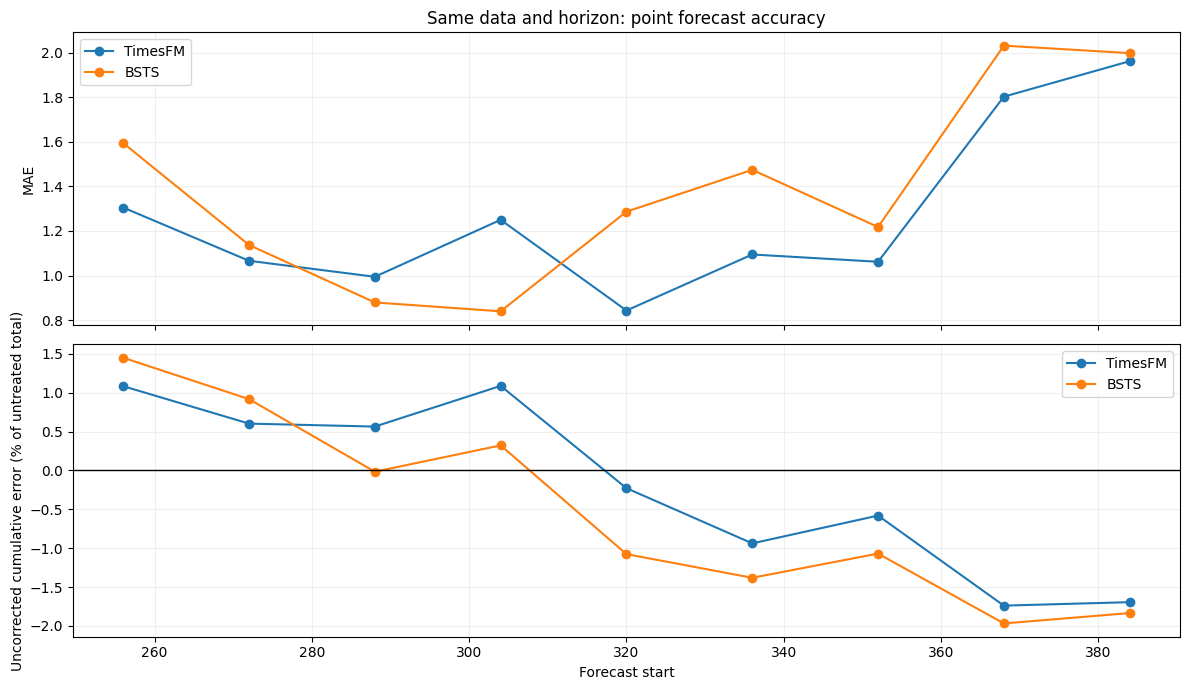

In [25]:
bsts_paths = pd.read_csv(bsts_dir / "paths.csv").pivot(
    index="cut", columns="horizon", values="forecast"
).sort_index(axis=1)
bsts_totals = pd.read_csv(bsts_dir / "totals.csv").set_index("cut")
assert list(bsts_paths.columns) == list(range(1, H + 1))
assert set(bsts_paths.index) == set(bsts_windows["cut"])
assert np.isfinite(bsts_paths.to_numpy()).all()
bsts_dev_forecasts = bsts_paths.loc[DEV_CUTS].to_numpy()
bsts_errors = actual_paths - bsts_dev_forecasts
bsts_cumulative = bsts_errors.sum(axis=1)
assert np.allclose(bsts_cumulative, bsts_totals.loc[DEV_CUTS, "effect"], atol=1e-3)

comparison_rows = []
for name, errors in [("TimesFM", placebo_paths), ("BSTS", bsts_errors)]:
    for i, cut in enumerate(DEV_CUTS):
        comparison_rows.append({
            "model": name, "cut": cut, "MAE": np.abs(errors[i]).mean(),
            "MAE_pct": 100 * np.abs(errors[i]).mean() / actual_paths[i].mean(),
            "cumulative_error_pct": 100 * errors[i].sum() / actual_paths[i].sum(),
        })
bsts_comparison = pd.DataFrame(comparison_rows)
display(bsts_comparison.rename(columns={
    "model": "모델", "cut": "예측 시작점", "MAE_pct": "MAE / 관측 평균 (%)",
    "cumulative_error_pct": "보정 전 누적 오차 / 관측 합계 (%)",
}).round(3))
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for name, group in bsts_comparison.groupby("model", sort=False):
    axes[0].plot(group["cut"], group["MAE"], "o-", label=name)
    axes[1].plot(group["cut"], group["cumulative_error_pct"], "o-", label=name)
axes[0].set_ylabel("MAE")
axes[0].set_title("Same data and horizon: point forecast accuracy")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Uncorrected cumulative error (% of untreated total)")
axes[1].set_xlabel("Forecast start")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## A4. 効果がない場合の区間も比較する

3つの方法を並べて見ます。**TimesFM + 経験的補正**と**BSTS + 同じ経験的補正**の差は、予測器を変えた場合の差です。
**BSTS自体の事後区間**は、予測器と不確実性の計算方法を組み合わせた結果です。これに経験的なバイアス補正をさらに加えることはしません。

以下の表の「0を含まない割合（%）」（原表：`0 미포함 (%)`）が小さくても、区間が広すぎると小さな効果を見つけにくくなります。
区間全体の幅と、次の節の効果注入の結果を併せて読んでください。0〜1の比率ではなく、0〜100の%で表示します。


,창 수,0 미포함 (%),절대 가짜 효과 / 관측 합계 중앙값 (%),구간 전체 폭 / 관측 합계 중앙값 (%)
method,,,,
TimesFM + empirical,9,44.444,1.109,2.956
BSTS + empirical,9,22.222,1.282,3.303
BSTS native,9,77.778,1.077,1.548


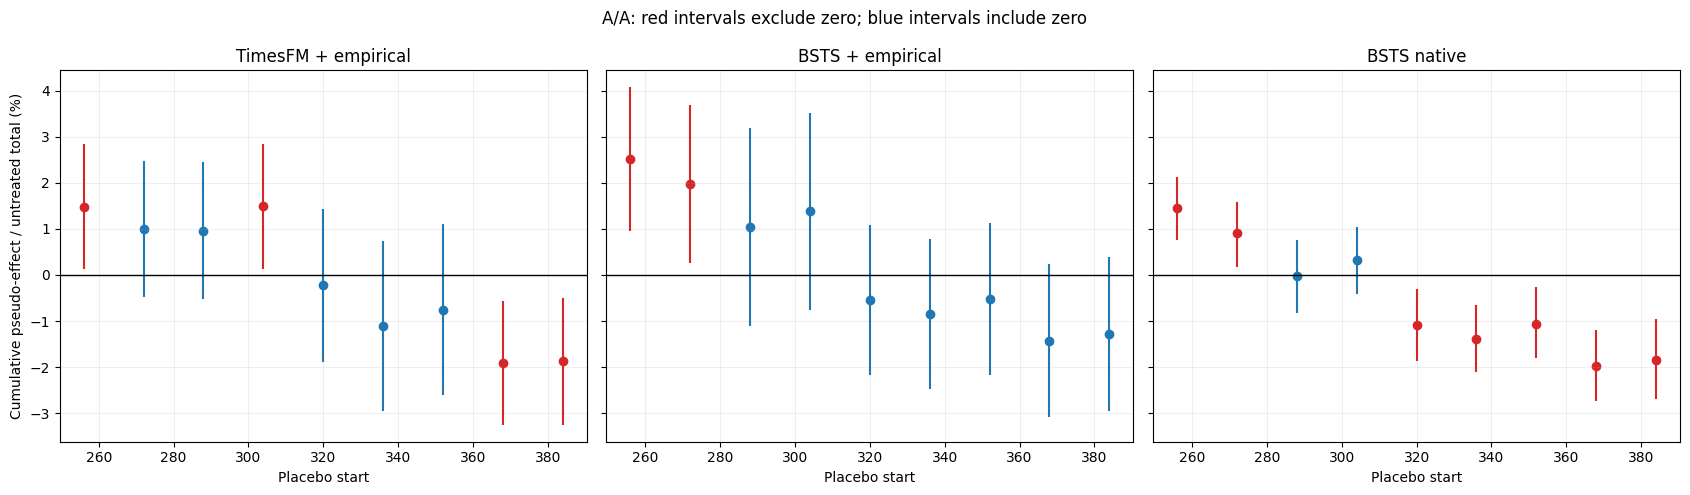

In [26]:
app_methods = ["TimesFM + empirical", "BSTS + empirical", "BSTS native"]
app_interval_rows = []
for i, cut in enumerate(DEV_CUTS):
    total = float(actual_paths[i].sum())
    for name, errors in [(app_methods[0], placebo_cumulative),
                         (app_methods[1], bsts_cumulative)]:
        bias, radius = leave_one_out_band(errors, i, level=AA_LEVEL)
        center = float(errors[i] - bias)
        app_interval_rows.append(dict(
            method=name, cut=cut, center=center, lower=center-radius,
            upper=center+radius, untreated_total=total,
        ))
    native = bsts_totals.loc[cut]
    app_interval_rows.append(dict(
        method=app_methods[2], cut=cut, center=native["effect"],
        lower=native["lower"], upper=native["upper"], untreated_total=total,
    ))
app_aa = pd.DataFrame(app_interval_rows)
app_aa["excludes_zero"] = (app_aa["lower"] > 0) | (app_aa["upper"] < 0)
app_aa["width_pct"] = 100 * (app_aa["upper"] - app_aa["lower"]) / app_aa["untreated_total"]
app_aa["abs_error_pct"] = 100 * app_aa["center"].abs() / app_aa["untreated_total"]
display(app_aa.groupby("method", sort=False).agg(**{
    "창 수": ("cut", "count"),
    "0 미포함 (%)": ("excludes_zero", lambda x: 100 * x.mean()),
    "절대 가짜 효과 / 관측 합계 중앙값 (%)": ("abs_error_pct", "median"),
    "구간 전체 폭 / 관측 합계 중앙값 (%)": ("width_pct", "median"),
}).round(3))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, method in zip(axes, app_methods):
    group = app_aa.loc[app_aa["method"] == method]
    # Draw intervals independently from the mean: posterior means need not
    # be centered within equal-tail credible intervals.
    for row in group.itertuples():
        scale = 100 / row.untreated_total
        color = "tab:red" if row.excludes_zero else "tab:blue"
        ax.vlines(row.cut, row.lower * scale, row.upper * scale, color=color)
        ax.scatter(row.cut, row.center * scale, color=color)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(method)
    ax.set_xlabel("Placebo start")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Cumulative pseudo-effect / untreated total (%)")
fig.suptitle("A/A: red intervals exclude zero; blue intervals include zero")
plt.tight_layout()
plt.show()

## A5. +2%、+5%、+10%の効果を加えるとどうなる？

本文と同じ割合の効果を、結果変数だけに加えます。過去の入力と対照変数は変わらないため、予測器を再学習する必要はありません。
BSTS自体の区間も、同じ予測分布を保ったまま、加えた累積効果の分だけ移動させます。

この表では正の効果を加えたため、**区間の下限が0より大きい場合**を正の効果の検出として数えます。
本文の方向を区別しない検出率とは定義が異なります。付録では3つの方法すべてに同じ定義を使います。
平均絶対相対誤差は、加えた効果そのものと比較します。20%なら、関心のある効果量の平均20%分だけ外れたという意味です。


In [27]:
app_injection_rows = []
for lift in INJECTED_LIFTS:
    for row in app_aa.itertuples():
        true_effect = lift * row.untreated_total
        estimate = row.center + true_effect
        lower = row.lower + true_effect
        upper = row.upper + true_effect
        app_injection_rows.append(dict(
            method=row.method, lift_pct=100 * lift,
            absolute_relative_error_pct=100 * abs(estimate - true_effect) / true_effect,
            positive_detection=lower > 0,
        ))
app_injection = pd.DataFrame(app_injection_rows)
display(app_injection.groupby(["method", "lift_pct"], sort=False).agg(**{
    "평균 절대 상대오차 (%)": ("absolute_relative_error_pct", "mean"),
    "양의 효과 검출 (%)": ("positive_detection", lambda x: 100 * x.mean()),
}).rename_axis(index=["방법", "주입 효과 (%)"]).round(3))

,,평균 절대 상대오차 (%),양의 효과 검출 (%)
방법,주입 효과 (%),,
TimesFM + empirical,2.0,59.990,55.556
BSTS + empirical,2.0,63.947,44.444
BSTS native,2.0,55.771,66.667
TimesFM + empirical,5.0,23.996,100.000
BSTS + empirical,5.0,25.579,100.000
BSTS native,5.0,22.308,100.000
TimesFM + empirical,10.0,11.998,100.000
BSTS + empirical,10.0,12.789,100.000
BSTS native,10.0,11.154,100.000


## A6. 最後のA/Aと実際の効果の例も、同じ設定で見る

経験的な補正値は、各モデルの**全開発ウィンドウ**だけから求めます。最後のA/Aや実際の介入結果に合わせて調整し直しません。
BSTS自体の事後区間には、この経験的補正を適用しません。
実際の効果の真値は、合成データでの答え合わせに使います。真値を知ったうえで設定を選ぶためには使いません。


In [28]:
bsts_bias, bsts_radius = empirical_error_band(bsts_cumulative, level=AA_LEVEL)
app_final_rows = []
for stage, cut, actual, tf_forecast, truth in [
    ("마지막 A/A", FINAL_AA_CUT, final_actual, final_cf, 0.0),
    ("실제 효과 예시", PRE, observed_post, real_cf, float(effect_positive[PRE:].sum())),
]:
    for name, forecast, bias, radius in [
        (app_methods[0], tf_forecast, dev_bias, dev_radius),
        (app_methods[1], bsts_paths.loc[cut].to_numpy(), bsts_bias, bsts_radius),
    ]:
        center = float((actual - forecast).sum() - bias)
        app_final_rows.append(dict(
            stage=stage, method=name, estimate=center,
            lower=center-radius, upper=center+radius, truth=truth,
        ))
    native = bsts_totals.loc[cut]
    app_final_rows.append(dict(
        stage=stage, method=app_methods[2], estimate=native["effect"],
        lower=native["lower"], upper=native["upper"], truth=truth,
    ))
app_final = pd.DataFrame(app_final_rows)
app_final["0 포함"] = (app_final["lower"] <= 0) & (app_final["upper"] >= 0)
app_final["정답 포함"] = (app_final["lower"] <= app_final["truth"]) & (app_final["upper"] >= app_final["truth"])
display(app_final.rename(columns={
    "stage": "구간", "method": "방법", "estimate": "누적효과 추정",
    "lower": "하한", "upper": "상한", "truth": "참 누적효과",
}).round(3))

,구간,방법,누적효과 추정,하한,상한,참 누적효과,0 포함,정답 포함
0,마지막 A/A,TimesFM + empirical,47.836,-48.179,143.851,0.000,True,True
1,마지막 A/A,BSTS + empirical,89.839,-50.431,230.110,0.000,True,True
2,마지막 A/A,BSTS native,18.884,-45.783,87.099,0.000,True,True
3,실제 효과 예시,TimesFM + empirical,576.064,480.049,672.078,634.753,False,True
4,실제 효과 예시,BSTS + empirical,629.519,489.248,769.790,634.753,False,True
5,실제 효과 예시,BSTS native,558.564,497.158,621.935,634.753,False,False


## 比較結果の読み方

| 観察される様子 | 解釈 |
|---|---|
| BSTSのMAEと累積誤差が、どちらも小さい。 | 今回のデータ構造では、BSTSの予測がより正確だったということです。ほかのデータ構造でも同じとは一般化しません。 |
| MAEは似ているが、一方の見かけの効果が小さい。 | 時点別の誤差の大きさが似ていても、同じ方向に累積する程度は異なる場合があります。効果推定では、この違いも重要です。 |
| BSTS自体の区間では0を含まない割合が減ったが、区間が広い。 | 不確実性を広く見積もった結果かもしれません。小さな効果の検出率も併せて見る必要があります。 |
| 2つのBSTS方式で、点推定値や区間が異なる。 | 経験的な方式は過去のウィンドウのバイアスを差し引き、誤差半径を付けます。BSTS自体の方式は事後分布を使います。計算方法の違いです。 |
| 小さな効果の検出率は高いが、A/Aでも頻繁に0を含まない。 | 効果をよく検出するように見えても、見かけの効果も頻繁に報告する可能性があります。検出率だけで優れているとは判断しないでください。 |
| 両方の結果が似ている。 | 観測した条件では、性能差が小さい可能性があります。学習・設定・運用にかかる手間も選択基準になり得ます。 |

関心のある効果が+2%なら、まずA/Aの見かけの効果と区間の大きさを2%と比べ、
効果注入の表で、+2%の効果量の誤差と正の効果の検出率を併せて確認してください。
どの方法にも自動的な合格判定は付けません。

BSTSは事前分布とMCMC推定の影響を受けます。現在の設定は1つの比較条件であり、シードや反復数を変えた場合の結果の安定性と、収束も追加で点検する必要があります。
本文と同様に、重複する少数のウィンドウから得た割合は、一般的な偽陽性率や検出力を保証するものではありません。


### どちらがよいと考えればよい？

予測誤差が小さい方法が、効果推定でも常によいとは限りません。区間を広げれば見かけの効果を減らせますが、小さな効果を見逃す可能性があります。区間を狭めれば効果をより頻繁に検出する一方、効果がない場合にも、あると判断してしまう可能性があります。

そのため、**A/Aで見かけの効果がどのくらい現れるかと、関心のある大きさの効果をどのくらい検出し、その大きさも近く推定できるかを併せて**見てください。最後の1区間で真値に近かったことだけで、全体の性能を判断しないことも重要です。

複数の結果で優劣が分かれるなら、一方が常によいと結論づけるより、**自分たちの目的に必要な精度と不確実性の水準を、どちらの方法がよりよく満たすか**を検討すればよいでしょう。
